<a href="https://colab.research.google.com/github/w114050009-maker/MathAnalysisDataSci/blob/main/DataSciMath_HW2_HandWrittenClf(USP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image, ImageOps, ImageEnhance
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [ ]:
# copy database file from remote to local
from google.colab import drive
import shutil

file = "usps.h5"

try:
  remote_path = os.path.join("drive/MyDrive/Colab Notebooks/mathAnalysis", file)
except FileNotFoundError:
  print("File not found")
finally:
  path = os.path.join("sample_data", file)

if not os.path.exists(path):
  print("Copying file from remote to local..")
  drive.mount('/content/drive')
  shutil.copy(remote_path, path)

In [ ]:
# Function to add name and result into dataframe
df_table = pd.DataFrame()

def overall_pred_res(name, result, keep="last"):
    # Define row labels
    index = ["test accuracy", "my data 1", "my data 2"]

    # Build a column DataFrame with all three results
    new_col = pd.DataFrame(result,
                           columns=[name],
                           index=index)

    # Concatenate horizontally
    global df_table
    df_table = pd.concat([df_table, new_col], axis=1)

    if keep == "first":
        df_table = df_table.loc[:, ~df_table.columns.duplicated(keep="first")]
    elif keep == "last":
        df_table = df_table.loc[:, ~df_table.columns[::-1].duplicated(keep="first")[::-1]]
    elif keep == "none":
        df_table = df_table.loc[:, df_table.columns.drop_duplicates(keep=False)]

    return df_table

In [ ]:
# @title
def enhance_picture(in_file):
  img_array = np.array(in_file.convert("L"))
  # 二值化（確保文字是黑色）
  _, binary = cv2.threshold(img_array, 128, 255, cv2.THRESH_BINARY)

  # 定義膨脹核心（越大越粗）
  kernel = np.ones((2, 2), np.uint8)
  img_dilated = cv2.dilate(binary, kernel, iterations=1)

  # 轉回 PIL.Image 再做對比增強
  pil_img = Image.fromarray(img_dilated)
  # enhancer = ImageEnhance.Contrast(pil_img)
  # out_file = enhancer.enhance(2.0)

  return pil_img

- Image.NEAREST：最快但品質差（像素化）
- Image.BILINEAR：線性插值，適合中等縮放
- Image.BICUBIC：立方插值，品質比 BILINEAR 好
- Image.LANCZOS：高品質濾波器，適合極端縮小

In [ ]:
# Convert png to test dataset
# in_test_dataset1 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son1"
in_test_dataset1 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me"
in_test_dataset2 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son22"
in_test_dataset3 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son12"
out_test_dataset1 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1"
out_test_dataset2 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/28x28/son1"
out_test_dataset3 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2"
out_test_dataset4 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/28x28/son2"
out_test_dataset5 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3"
out_test_dataset6 = "drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/28x28/son3"

in_plan = [in_test_dataset1, in_test_dataset2, in_test_dataset3]
out_plan = [out_test_dataset1, out_test_dataset2, out_test_dataset3, out_test_dataset4, out_test_dataset5, out_test_dataset6]
size_plan = [[16,16], [28,28]]

for i in range(3):
  for j in range(10):
    picture = f"{j}.png"
    format = Image.LANCZOS

    filename = os.path.join(in_plan[i], picture)
    img = Image.open(filename).convert("L")  # 轉為灰階
    # img_np = np.array(img)
    # _, binary = cv2.threshold(img_np, 128, 255, cv2.THRESH_BINARY)

    # enhanced_img = enhance_picture(img)
    # enhanced_img = Image.fromarray(img_np)
    # img_inverted = ImageOps.invert(enhanced_img)

    img_resized = img.resize(size_plan[0],format)  # 調整大小16x16
    img_resized.save(os.path.join(out_plan[i*2], picture))  # 儲存處理後圖片

    img_resized = img.resize(size_plan[1], format)  # 調整大小28x28
    img_resized.save(os.path.join(out_plan[i*2+1], picture))  # 儲存處理後圖片
    print(f"Processed {filename}")


Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/0.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/1.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/2.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/3.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/4.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/5.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/6.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/7.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/8.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/9.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son22/0.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son22/1.png
Processed drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son22/2.png
Processed drive/

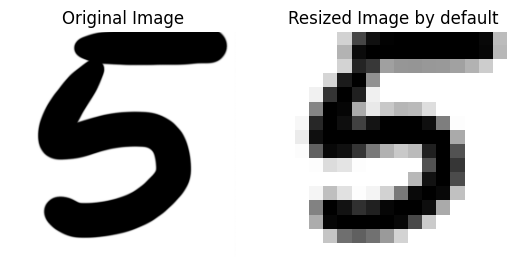

Original image size:  (250, 250)


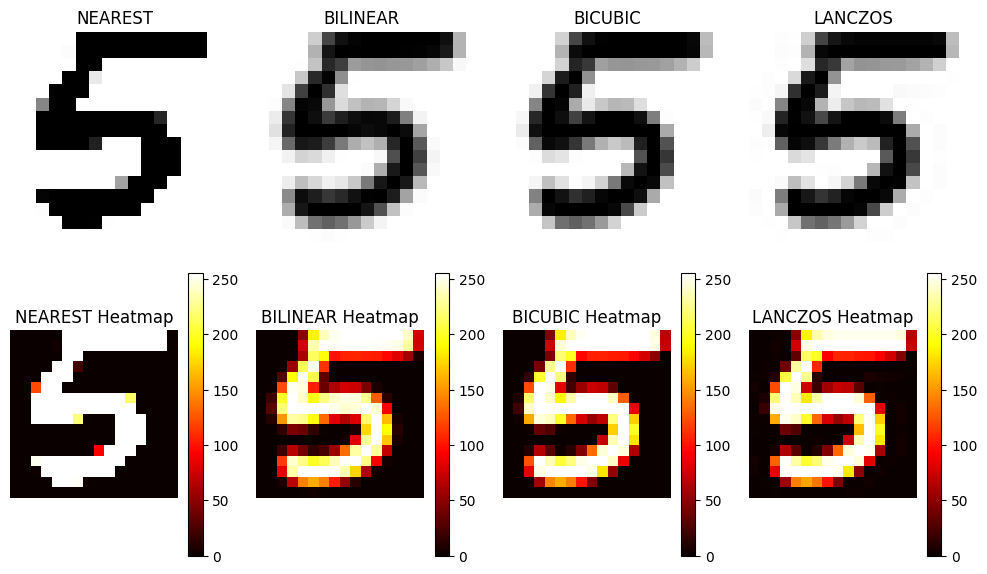

Resized image size:  (16, 16)


In [ ]:
# Compare 4 image formats
test_picture = "/content/drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/5.png"
img = Image.open(test_picture).convert("L")

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="binary")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(img.resize((16,16)), cmap="binary")
plt.axis("off")
plt.title("Resized Image by default")
plt.show()

print("Original image size: ", img.size)

methods = {
    "NEAREST": Image.NEAREST,
    "BILINEAR": Image.BILINEAR,
    "BICUBIC": Image.BICUBIC,
    "LANCZOS": Image.LANCZOS
}

# 縮小到 16x16 並顯示原圖 + heatmap
plt.figure(figsize=(10, 6))

for i, (name, method) in enumerate(methods.items(), 1):
    resized = img.resize((16, 16), method)
    arr = np.array(resized)

    # 左邊顯示影像
    plt.subplot(2, 4, i)
    plt.imshow(resized, cmap="binary")
    plt.title(name)
    plt.axis("off")

    # 右邊顯示 heatmap
    plt.subplot(2, 4, i+4)
    plt.imshow(arr, cmap="hot")
    plt.colorbar()
    plt.title(f"{name} Heatmap")
    plt.axis("off")

plt.tight_layout()
plt.show()
print("Resized image size: ", resized.size)

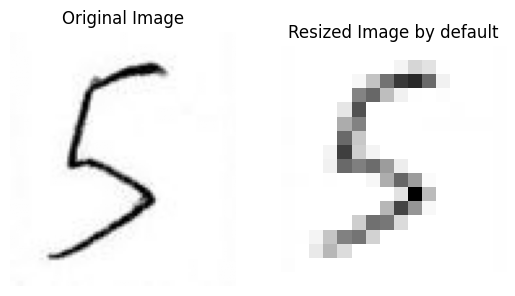

Original image size:  (87, 98)


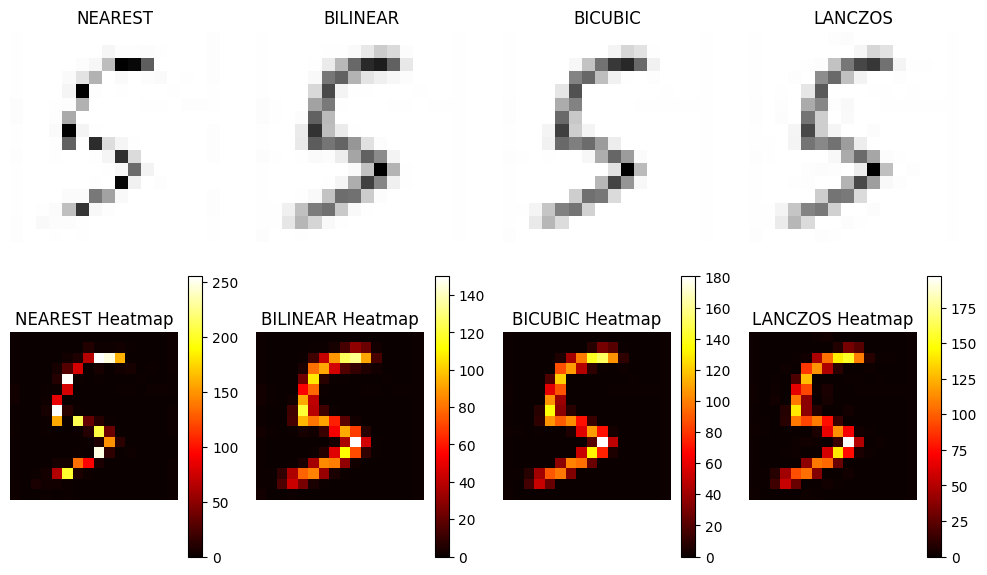

Resized image size:  (16, 16)


In [ ]:
# Compare 4 image formats
test_picture = "/content/drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/son12/5.png"
img = Image.open(test_picture).convert("L")

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="binary")
plt.axis("off")
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(img.resize((16,16)), cmap="binary")
plt.axis("off")
plt.title("Resized Image by default")
plt.show()

print("Original image size: ", img.size)

methods = {
    "NEAREST": Image.NEAREST,
    "BILINEAR": Image.BILINEAR,
    "BICUBIC": Image.BICUBIC,
    "LANCZOS": Image.LANCZOS
}

# 縮小到 16x16 並顯示原圖 + heatmap
plt.figure(figsize=(10, 6))

for i, (name, method) in enumerate(methods.items(), 1):
    resized = img.resize((16, 16), method)
    arr = np.array(resized)

    # 左邊顯示影像
    plt.subplot(2, 4, i)
    plt.imshow(resized, cmap="binary")
    plt.title(name)
    plt.axis("off")

    # 右邊顯示 heatmap
    plt.subplot(2, 4, i+4)
    plt.imshow(arr, cmap="hot")
    plt.colorbar()
    plt.title(f"{name} Heatmap")
    plt.axis("off")

plt.tight_layout()
plt.show()
print("Resized image size: ", resized.size)

In [ ]:
# @title
# Compare 4 image formats
test_picture = "/content/drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/me/5.png"
img = Image.open(test_picture).convert("L")

print("Original image size: ", img.size)
methods = {
    "NEAREST": Image.NEAREST,
    "BILINEAR": Image.BILINEAR,
    "BICUBIC": Image.BICUBIC,
    "LANCZOS": Image.LANCZOS
}

# 縮小到 16x16 並顯示
plt.figure(figsize=(10, 3))
for i, (name, method) in enumerate(methods.items(), 1):
    resized = img.resize((16, 16), method)
    plt.subplot(1, 4, i)
    plt.imshow(resized, cmap="binary")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
np.array(resized)/255

array([[0.        , 0.        , 0.00784314, 0.00392157, 0.18823529,
        0.73333333, 0.91764706, 0.96862745, 0.98431373, 0.98431373,
        0.98431373, 0.98431373, 0.98431373, 0.98431373, 0.96470588,
        0.25882353],
       [0.        , 0.        , 0.01176471, 0.00784314, 0.29411765,
        0.97254902, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        0.27843137],
       [0.        , 0.        , 0.00784314, 0.        , 0.12941176,
        0.84705882, 0.78039216, 0.36078431, 0.41960784, 0.41568627,
        0.4       , 0.39607843, 0.36078431, 0.29803922, 0.18431373,
        0.        ],
       [0.        , 0.00784314, 0.        , 0.14509804, 0.90588235,
        1.        , 0.42352941, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00392157],
       [0.00392157, 0.00784314, 0.03921569, 0.81176471, 1.        ,
        0.89019608, 0.04313725, 

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Example: pick one method from your dictionary
name, method = list(methods.items())[3]   # just take the first method
resized = img.resize((16, 16), method)

# Convert to NumPy array
arr = np.array(resized)

# Plot as heatmap
plt.figure(figsize=(4,4))
plt.imshow(arr, cmap="hot")   # try "viridis", "hot", "plasma", etc. for different looks
plt.colorbar(label="Pixel intensity")
plt.title(f"Heatmap of {name} resized image")
plt.axis("off")
plt.show()

In [ ]:
import h5py
from functools import reduce

def getUspDataSet(path):
  with h5py.File(path, 'r') as hf:
    train = hf.get('train')
    x_Train = train.get("data")[:]
    y_Train = train.get("target")[:]

    test = hf.get('test')
    x_Test = test.get("data")[:]
    y_Test = test.get("target")[:]
  return x_Train, y_Train, x_Test, y_Test

In [ ]:
def plot_image(image):
  fig = plt.gcf()
  fig.set_size_inches(2, 2)
  plt.imshow(image, cmap='binary')
  plt.show()

In [ ]:
def plot_images_labels_prediction(images,labels, prediction,idx,num=10):
  fig = plt.gcf()
  fig.set_size_inches(12, 14)
  if num>25: num=25
  for i in range(0, num):
    ax=plt.subplot(5,5, 1+i)
    ax.imshow(images.iloc[idx, np.arange(0, 256)].values.reshape([16, 16]), cmap='binary')
    title= "label=" +str(labels.iloc[idx,0])
    if len(prediction)>0:
      title+=",predict="+str(prediction.iloc[idx,0])

    ax.set_title(title,fontsize=10)
    ax.set_xticks([]);ax.set_yticks([])
    idx+=1
  plt.show()

## NumPy 的  在 2D 陣列上的行為：
*   對於 1D 向量， 是標準的歐式距離
*   對於 2D 矩陣， 是 矩陣的最大奇異值（spectral norm），不是元素平方和的平方根。

In [ ]:
# 2-norm
def norm2 (a, ak):
  # return np.linalg.norm(a-ak, ord='fro')
  return np.linalg.norm(a-ak, 2)

In [ ]:
# Get Train and Test dataset
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
# Concatenate features(column 0~255) and label(column 256)
x_Train_data = pd.concat([pd.DataFrame(x_Train),pd.DataFrame(y_Train, columns=['digital'])], axis=1)
x_Test_data = pd.concat([pd.DataFrame(x_Test),pd.DataFrame(y_Test, columns=['digital'])], axis=1)

In [ ]:
# Show data value
x_Train_data.iloc[0, np.arange(0, 256)].values.reshape([16, 16])

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.18450001, 0.93099999, 0.4165    ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00400001, 0.64849997, 1.        , 0.65350002,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.29500002, 1.        , 0.99300003, 0.2175    ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.15849999, 0.91250002, 1.        , 0.78100002, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.03099999,
        0.76999998, 1.        , 

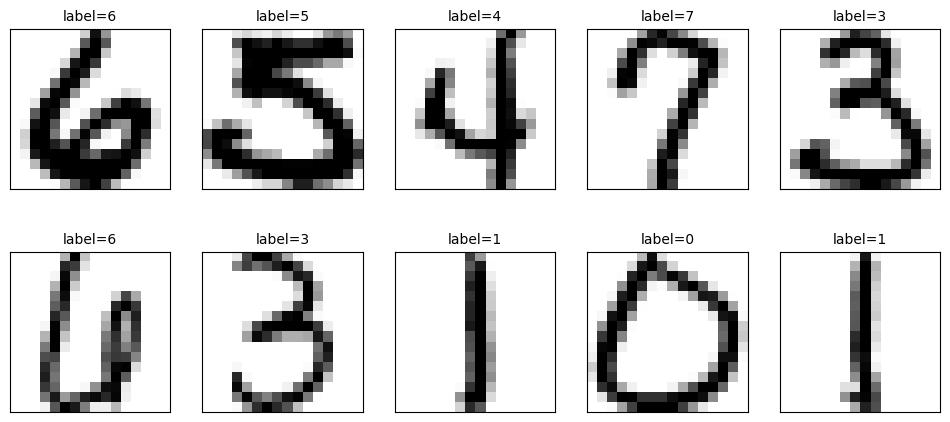

In [ ]:
# Train dataset
plot_images_labels_prediction(x_Train_data.loc[:,np.arange(0, 256)], x_Train_data.loc[:,['digital']],[],0,)

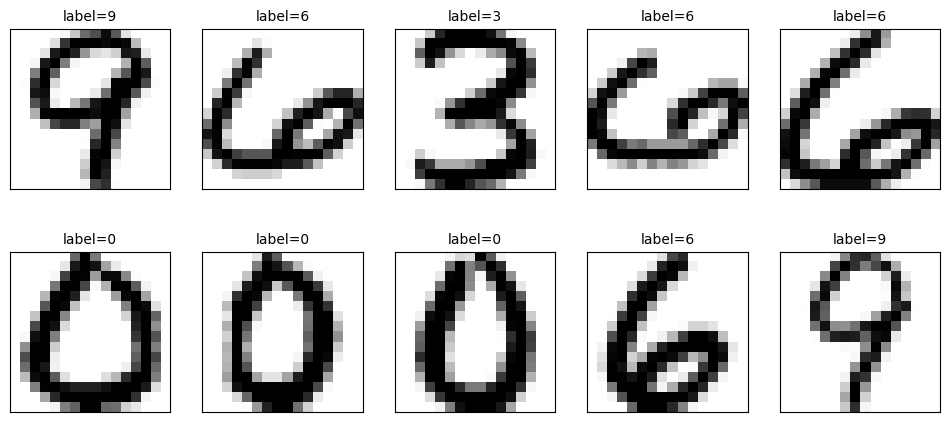

In [ ]:
# Test dataset
plot_images_labels_prediction(x_Test_data.loc[:,np.arange(0, 256)], x_Test_data.loc[:,['digital']],[],0,)

In [ ]:
feature_names = [str(i) for i in range(10)] + ['Total']

# 統計每個數字類別的樣本數（0–9），缺的補 0
train_counts = x_Train_data['digital'].value_counts().reindex(range(10), fill_value=0).to_numpy()
test_counts = x_Test_data['digital'].value_counts().reindex(range(10), fill_value=0).to_numpy()

# 加上總數
train_row = np.append(train_counts, x_Train_data.shape[0])
test_row = np.append(test_counts, x_Test_data.shape[0])

# 組成 DataFrame
df = pd.DataFrame([train_row, test_row], columns=feature_names, index=["Train", "Test"])
df

,0,1,2,3,4,5,6,7,8,9,Total
Train,1194,1005,731,658,652,556,664,645,542,644,7291
Test,359,264,198,166,200,160,170,147,166,177,2007


In [ ]:
# @title
# feature_names = np.array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'Total'])

# table = np.zeros((2, 11))

# for i in range(11):
#   table[0][i] = x_Train_data[x_Train_data['digital'] == i].shape[0]
#   table[1][i] = x_Test_data[x_Test_data['digital'] == i].shape[0]
#   if i == 10: # total
#     table[0][i] = x_Train_data.shape[0]
#     table[1][i] = x_Test_data.shape[0]

# df = pd.DataFrame(table, columns=feature_names, index=["Train","Test"])
# df

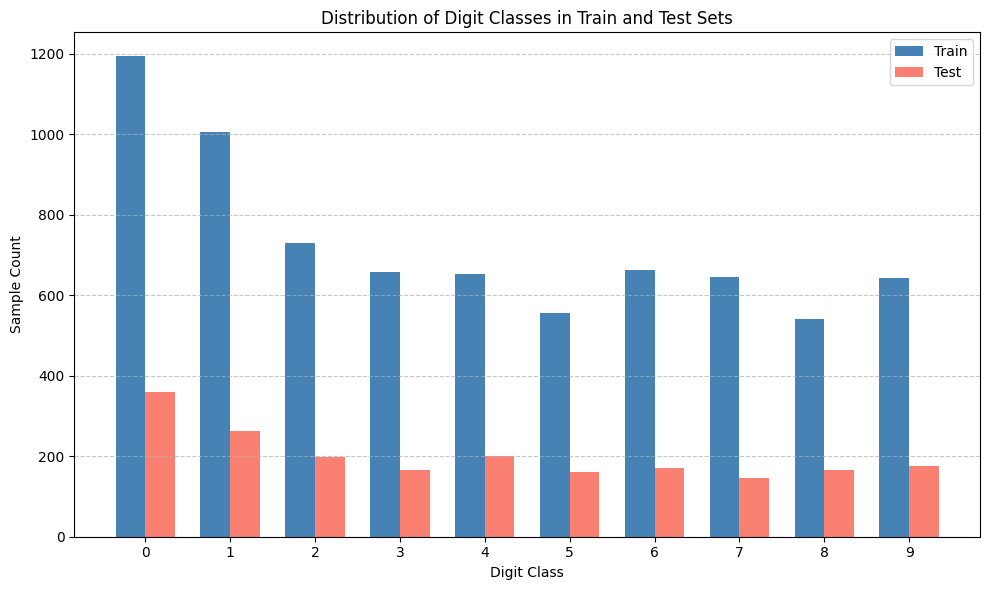

In [ ]:
x = np.arange(len(feature_names) - 1)  # 0–9
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df.loc["Train"][:-1], width, label='Train', color='steelblue')
plt.bar(x + width/2, df.loc["Test"][:-1], width, label='Test', color='salmon')

plt.xticks(x, feature_names[:-1])
plt.xlabel('Digit Class')
plt.ylabel('Sample Count')
plt.title('Distribution of Digit Classes in Train and Test Sets')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


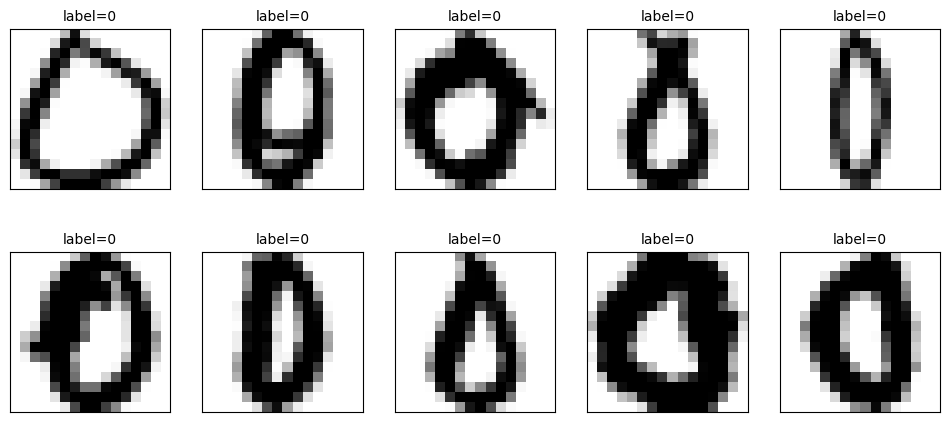

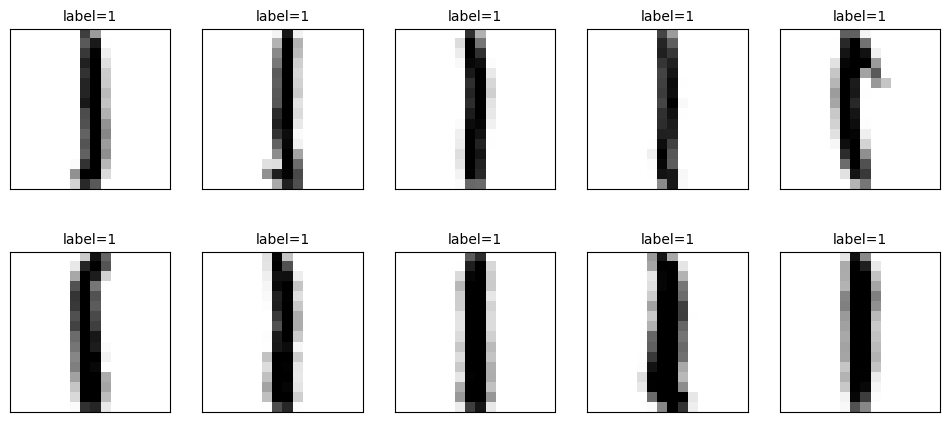

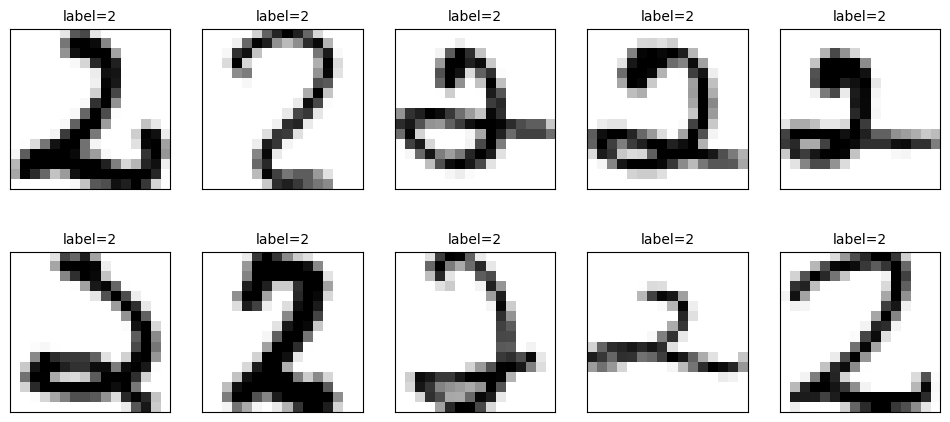

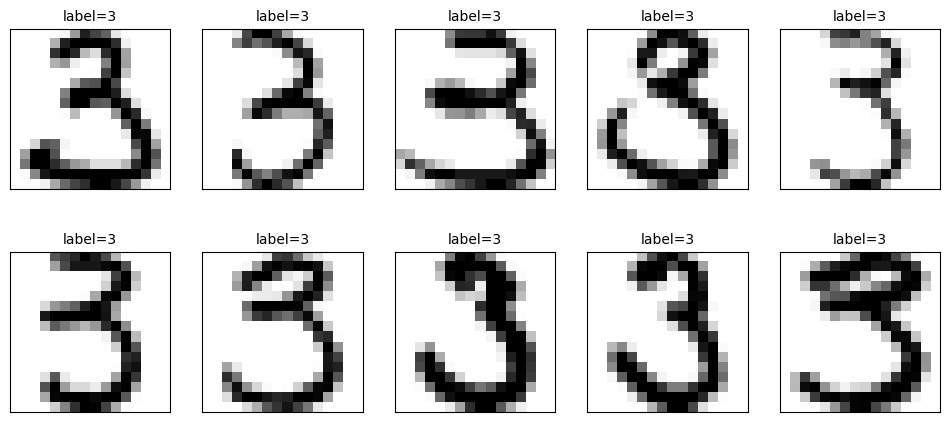

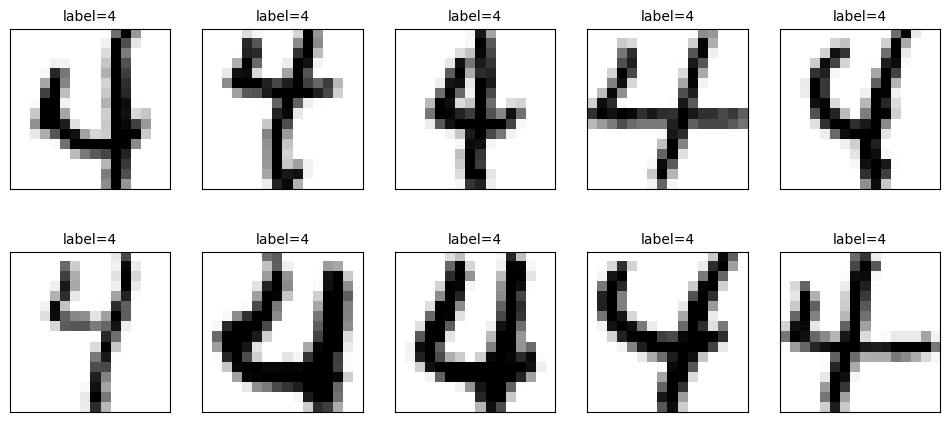

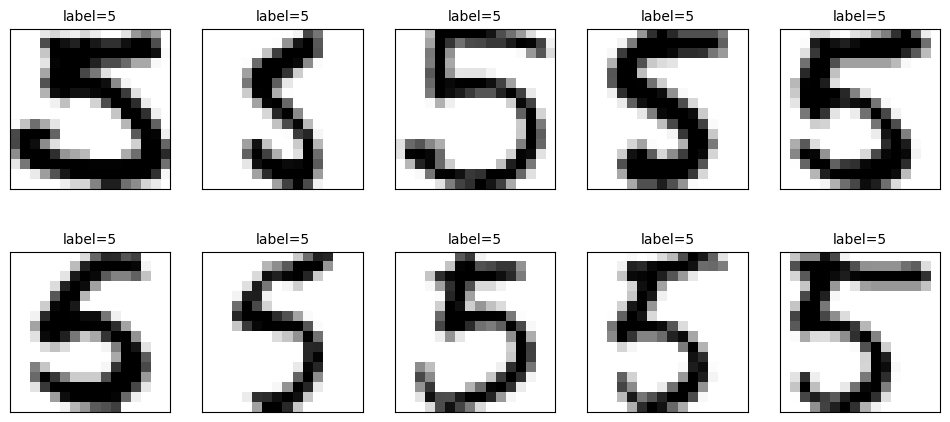

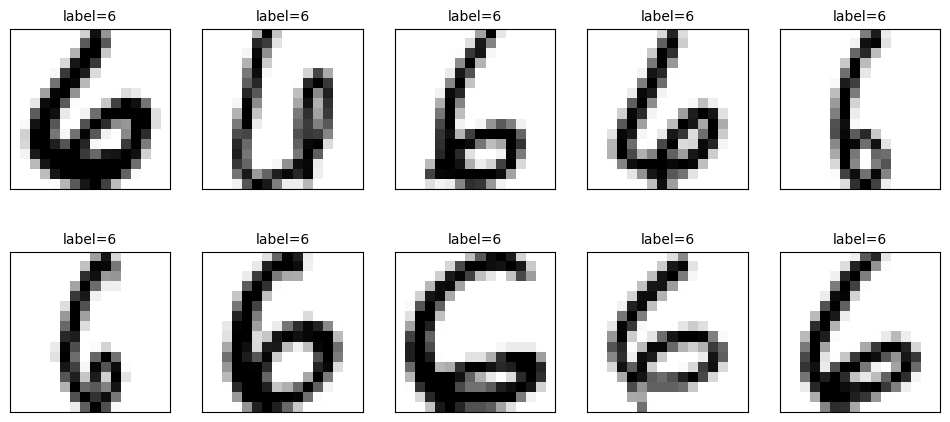

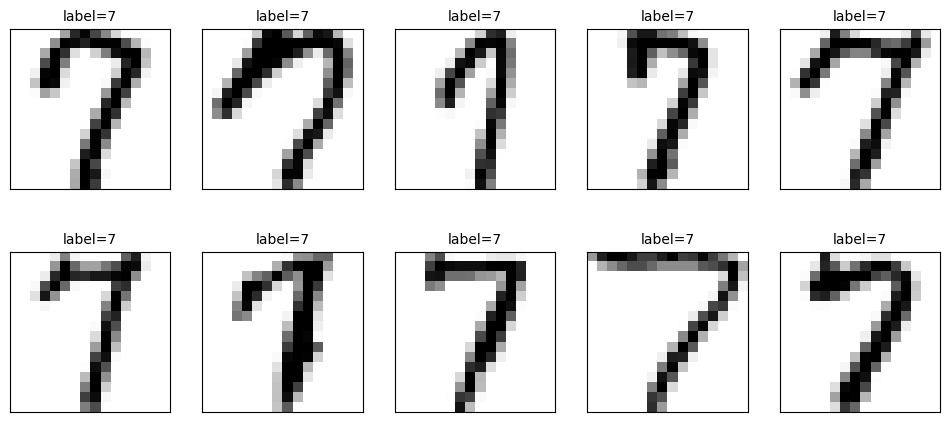

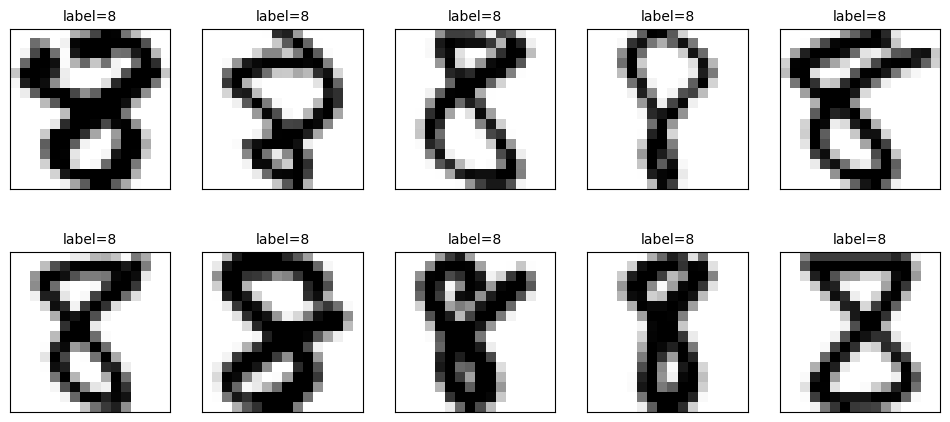

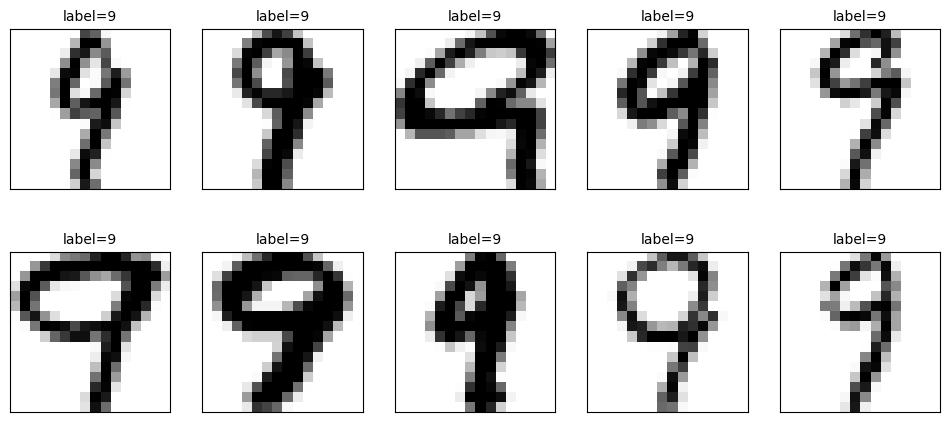

In [ ]:
for i in range(0,10):
  plot_images_labels_prediction(x_Train_data[x_Train_data['digital'] == i].loc[:,np.arange(0, 256)], x_Train_data[x_Train_data['digital'] == i].loc[:,['digital']],[],0,)

# Handwritten Digits and a Simple Algorithm(Mean)

### 透過 training set 取得手寫數字0~9的平均值陣列
### 將 testing set 每一張手寫數字與0~9平均值陣列比對，取最小的2norm，預測該張手寫數字代表的數字

In [ ]:
# @title
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

In [ ]:
# @title
x_Train_data = pd.concat([pd.DataFrame(x_Train),pd.DataFrame(y_Train, columns=['digital'])], axis=1)
x_Test_data = pd.concat([pd.DataFrame(x_Test),pd.DataFrame(y_Test, columns=['digital'])], axis=1)

In [ ]:
# @title
# def getMeanDigitalTable(x_Data, y_Data):
#   x_Data_list = pd.concat([pd.DataFrame(x_Data),pd.DataFrame(y_Data, columns=['digital'])], axis=1)
#   meanDigitalTable = np.zeros((10, 257))

#   for i in range(10):
#     for j in range(257):
#       if j == 256:
#         meanDigitalTable[i][j] = int(i)
#       else:
#         meanDigitalTable[i][j] = x_Data_list[x_Data_list['digital'] == i].loc[:,np.arange(0, 256)].mean(axis = 0)[j]

#   x_Train_mean = pd.DataFrame(meanDigitalTable, columns=np.arange(0, 257))

#   return x_Train_mean

In [ ]:
def getMeanDigitalTable(x_Data, y_Data):
    df = pd.DataFrame(x_Data)
    df['digital'] = y_Data

    # 計算每個數字類別的平均像素（0~255）
    mean_table = df.groupby('digital').mean()

    # 加上第256欄作為標籤欄位
    mean_table[256] = mean_table.index

    # 重新排序欄位，讓標籤在最後
    mean_table = mean_table[np.append(np.arange(0, 256), 256)]

    return mean_table.reset_index(drop=True)

In [ ]:
x_Train_mean = getMeanDigitalTable(x_Train, y_Train)
x_Train_mean

,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,256
0,0.000686,0.002301,0.007539,0.029374,0.083329,0.214289,0.434208,0.576304,0.523142,0.323150,...,0.764013,0.719526,0.521244,0.266493,0.087247,0.016245,0.001737,3.182578e-05,0.000000,0
1,0.000000,0.000000,0.000000,0.000000,0.000002,0.006361,0.182422,0.738624,0.499852,0.059166,...,0.575412,0.754635,0.216239,0.019953,0.001869,0.000331,0.000234,0.000000e+00,0.000000,1
2,0.003756,0.019804,0.048712,0.100327,0.198269,0.313164,0.402114,0.423611,0.339817,0.187808,...,0.159382,0.109233,0.081786,0.078753,0.102215,0.140904,0.138408,8.737893e-02,0.025574,2
3,0.001242,0.009779,0.043731,0.134705,0.290489,0.448432,0.579752,0.669148,0.673355,0.563835,...,0.705606,0.651247,0.520859,0.352631,0.195606,0.089490,0.033318,7.094225e-03,0.000089,3
4,0.000000,0.000457,0.004272,0.020956,0.060340,0.107799,0.091428,0.077067,0.086249,0.130354,...,0.241590,0.326567,0.282333,0.163329,0.071298,0.028863,0.007327,2.269172e-03,0.000263,4
5,0.000271,0.002451,0.014165,0.033097,0.058937,0.098799,0.146969,0.233636,0.316099,0.395971,...,0.641636,0.643503,0.567831,0.409600,0.244072,0.110748,0.038295,9.165468e-03,0.000859,5
6,0.000000,0.000000,0.000000,0.000455,0.003624,0.016902,0.065898,0.214449,0.438809,0.468584,...,0.722267,0.618303,0.402012,0.190471,0.071111,0.015579,0.002254,7.530023e-07,0.000000,6
7,0.012542,0.060091,0.118027,0.198057,0.291024,0.351520,0.381180,0.397761,0.428757,0.457081,...,0.535655,0.373433,0.096324,0.011988,0.002297,0.000408,0.000000,0.000000e+00,0.000000,7
8,0.000749,0.007785,0.030420,0.085137,0.199803,0.370611,0.550061,0.634461,0.606877,0.468825,...,0.791119,0.782972,0.539287,0.231089,0.071608,0.014589,0.002356,1.844995e-06,0.000000,8
9,0.000050,0.000721,0.002192,0.009234,0.030633,0.109248,0.301347,0.582745,0.786200,0.759811,...,0.490326,0.462094,0.212839,0.063462,0.018492,0.004843,0.001668,5.302795e-04,0.000000,9


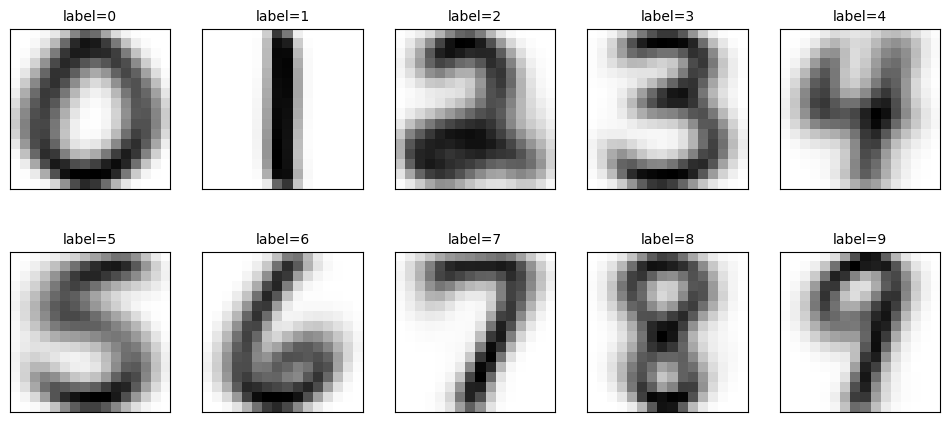

In [ ]:
# Show digits of mean
plot_images_labels_prediction(x_Train_mean.loc[:,np.arange(0, 256)], x_Train_mean.loc[:,[256]],[],0,10)

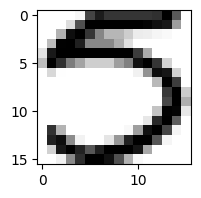

In [ ]:
# Test dataset
plot_image(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 256)].values[0].reshape([16, 16]))
# plot_image(x_Test_data.iloc[2, np.arange(0, 256)].values.reshape([16, 16]))

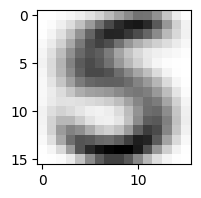

In [ ]:
# Mean
plot_image(x_Train_mean.iloc[5, np.arange(0, 256)].values.reshape([16, 16]))

In [ ]:
# @title
# norm2(x_Test_data.iloc[2, np.arange(0, 256)].values.reshape([16, 16]), x_Train_mean.iloc[2, np.arange(0, 256)].values.reshape([16, 16]))
# Get 2-norm of test_data_digit_8 and train_data_mean_digit_3
norm2(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 256)].values[0].reshape([16, 16]), x_Train_mean.iloc[5, np.arange(0, 256)].values.reshape([16, 16]))

np.float64(3.822268270680308)

In [ ]:
df_means = pd.DataFrame(np.zeros((1,10)))
for i in range(10):
  df_means[i] = norm2(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 256)].values[0].reshape([16, 16]), x_Train_mean.iloc[i, np.arange(0, 256)].values.reshape([16, 16]))
  df_means.columns = np.arange(10)
  df_means.index = ['residual value with digit 5']
df_means

,0,1,2,3,4,5,6,7,8,9
residual value with digit 5,3.935928,5.684897,5.039012,3.912337,5.632221,3.822268,5.077096,4.591648,5.067182,4.845156


In [ ]:
print(f"Minimal residual value= {df_means.min().min()}"
      f"which is digit {df_means.min().idxmin()}")

Minimal residual value= 3.822268270680308which is digit 5


In [ ]:
# @title
# Get 2-norm of test_data_digit_8 and train_data_mean_digit_8
np.linalg.norm(x_Test_data[x_Test_data['digital'] == 3].loc[:,np.arange(0, 256)].values[0] - x_Train_mean.iloc[3, np.arange(0, 256)].values, 2)

np.float64(4.386644442056621)

In [ ]:
# @title
x_Test_data.shape

In [ ]:
def simpleAlgorithm(x_Test_data, x_Train_mean):
  total = x_Test_data.shape[0]
  # isSuccess = 0
  # isError = 0
  result = np.zeros((total, 1))
  result_residual = np.zeros(total)
  result_residual_list = []

  for i in range(0, total):
    normList = np.zeros((1, 10))

    for j in range(0,10):
        residual_list = np.ones((10))

        normValue = norm2(x_Test_data.iloc[i, np.arange(0, 256)].values.reshape([16, 16]), x_Train_mean.iloc[j, np.arange(0, 256)].values.reshape([16, 16]))
        normList[0][j] = normValue
    prediction = np.where(normList == np.amin(normList))
    result[i][0] = int(prediction[1][0])
    result_residual[i] = np.amin(normList)
    result_residual_list.append(normList[0])

  tempPd = pd.concat([x_Test_data, pd.DataFrame(result, columns=['prediction'])], axis=1)
  x_Test_Prediction = pd.concat([tempPd, pd.DataFrame(result_residual, columns=['residual'])], axis=1)
  x_Test_result = x_Test_Prediction[x_Test_Prediction['digital'] == x_Test_Prediction['prediction']].shape[0]/x_Test_Prediction.shape[0]

  return x_Test_Prediction, x_Test_result, result_residual_list

In [ ]:
# @title
def compareAlgorithm(x_Test_data, x_Train_mean):
  total = x_Test_data.shape[0] # rows
  result = np.zeros((total, 1), dtype=int)
  result_residual = np.zeros(total)
  result_residual_list = []

  # 取出平均圖像（10×256）
  mean_vectors = x_Train_mean.iloc[:, :256].values

  for i in range(total):
    test_vector = x_Test_data.iloc[i, :256].values
    # 計算與每個類別(0-9)平均圖像的 L2 距離
    distances = np.linalg.norm(mean_vectors - test_vector, axis=1)
    # distances = np.linalg.norm(test_vector - mean_vectors, axis=1)
    prediction = np.argmin(distances)

    result[i, 0] = prediction
    result_residual[i] = distances[prediction]
    result_residual_list.append(distances)

  # 結果合併 column from 257 to 259
  x_Test_Prediction = x_Test_data.copy()
  x_Test_Prediction['prediction'] = result # add col='prediction'
  x_Test_Prediction['residual'] = result_residual # add col='residual'

  # 計算準確率
  # accuracy = x_Test_Prediction[x_Test_Prediction['digital'] == x_Test_Prediction['prediction']].shape[0]/x_Test_Prediction.shape[0]
  accuracy = (x_Test_Prediction['digital'] == x_Test_Prediction['prediction']).mean()

  return x_Test_Prediction, accuracy, result_residual_list

In [ ]:
# x_Test_Prediction, x_Test_result, result_Test_residual = compareAlgorithm(x_Test_data, x_Train_mean)
x_Test_Prediction, x_Test_result, result_Test_residual = simpleAlgorithm(x_Test_data, x_Train_mean)

In [ ]:
x_Test_Prediction[x_Test_Prediction['prediction'] != x_Test_Prediction['digital']].shape[0]

448

In [ ]:
print("準確率為 :", x_Test_result)

準確率為 : 0.7767812655705032


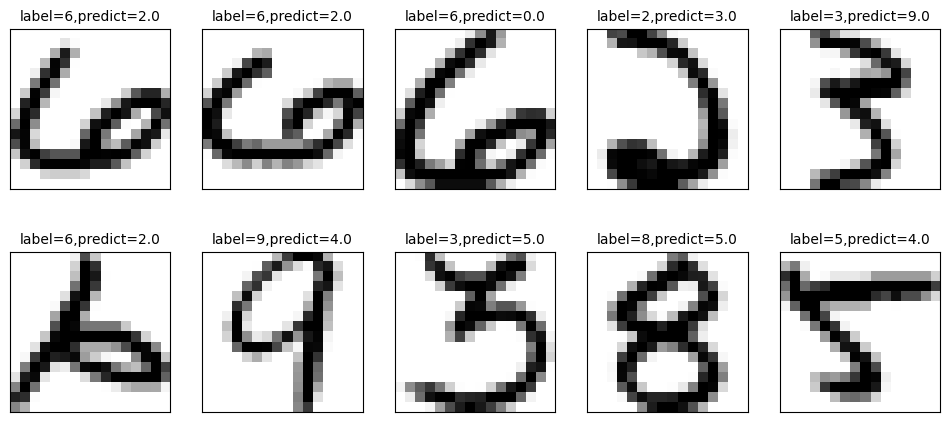

In [ ]:
errorList = x_Test_Prediction[x_Test_Prediction['digital'] != x_Test_Prediction['prediction']]

plot_images_labels_prediction(errorList.iloc[:,np.arange(0, 256)], errorList.iloc[:,[256]], errorList.iloc[:,[257]],0,10)

In [ ]:
# @title
# totalCounts = x_Test_Prediction[['digital']].groupby(['digital']).size().reset_index(name='totalCounts')
# totalCounts = totalCounts.sort_values('digital', ascending=[True])
# errorCounts = errorList[['digital']].groupby(['digital']).size().reset_index(name='errorCounts')
# errorCounts = errorCounts.sort_values('digital', ascending=[True])
# resultdf = pd.concat([totalCounts,pd.DataFrame(errorCounts, columns=['errorCounts'])], axis=1)
# resultdf["successCounts"] = resultdf["totalCounts"]-resultdf["errorCounts"]
# resultdf["probability"] = (resultdf["totalCounts"]-resultdf["errorCounts"])/resultdf["totalCounts"]
# resultdf.sort_values('probability', ascending=[False])

In [ ]:
# 計算每個數字的總預測數
totalCounts = x_Test_Prediction['digital'].value_counts().sort_index().rename('totalCounts')

# 計算每個數字的錯誤數
errorCounts = errorList['digital'].value_counts().sort_index().rename('errorCounts')

# 合併成一個 DataFrame，缺失值填 0
resultdf = pd.concat([totalCounts, errorCounts], axis=1).fillna(0)

# 計算成功數與成功率
resultdf['errorCounts'] = resultdf['errorCounts'].astype(int)
resultdf['successCounts'] = resultdf['totalCounts'] - resultdf['errorCounts']
resultdf['probability'] = resultdf['successCounts'] / resultdf['totalCounts']

# 依成功率排序
resultdf = resultdf.sort_values('probability', ascending=False).reset_index()
resultdf

,digital,totalCounts,errorCounts,successCounts,probability
0,1,264,12,252,0.954545
1,0,359,63,296,0.824513
2,6,170,33,137,0.805882
3,7,147,29,118,0.802721
4,9,177,35,142,0.802260
5,4,200,58,142,0.710000
6,3,166,50,116,0.698795
7,8,166,52,114,0.686747
8,2,198,63,135,0.681818
9,5,160,53,107,0.668750


In [ ]:
# @title
# temp = errorList[['digital', 'prediction']].groupby(['digital', 'prediction']).size().reset_index(name='counts')
# errorPrediction = np.zeros((4, 10))

# for i in range(0,10):
#   errorPrediction[0][i] = temp[temp['digital'] == i].sort_values(['digital', 'counts'], ascending=[True, False]).iloc[0,1]
#   errorPrediction[1][i] = temp[temp['digital'] == i].sort_values(['digital', 'counts'], ascending=[True, False]).iloc[0,2]
#   errorPrediction[2][i] = temp[temp['digital'] == i].sort_values(['digital', 'counts'], ascending=[True, False]).iloc[1,1]
#   errorPrediction[3][i] = temp[temp['digital'] == i].sort_values(['digital', 'counts'], ascending=[True, False]).iloc[1,2]

# pd.DataFrame(errorPrediction, columns=np.arange(0, 10))

In [ ]:
# 計算每個 (digital, prediction) 的錯誤次數
temp = (
    errorList[['digital', 'prediction']]
    .groupby(['digital', 'prediction'])
    .size()
    .reset_index(name='counts')
)

# 建立空的錯誤預測矩陣：4 × 10
errorPrediction = np.zeros((4, 10))

# 對每個真實數字 i，找出最常見的兩個錯誤預測
for i in range(10):
  top_errors = (
      temp[temp['digital'] == i]
      .sort_values('counts', ascending=False)
      .head(2)
  )
  if len(top_errors) > 0:
      errorPrediction[0][i] = top_errors.iloc[0]['prediction']
      errorPrediction[1][i] = top_errors.iloc[0]['counts']
  if len(top_errors) > 1:
      errorPrediction[2][i] = top_errors.iloc[1]['prediction']
      errorPrediction[3][i] = top_errors.iloc[1]['counts']

# 包裝成 DataFrame
error_df = pd.DataFrame(errorPrediction, columns=np.arange(10))
error_df.index = ["1st wrongly predicted digit", "Qty", "2nd wrongly predicted digit", "Qty"]
error_df

,0,1,2,3,4,5,6,7,8,9
1st wrongly predicted digit,6.0,9.0,4.0,5.0,9.0,3.0,0.0,9.0,5.0,4.0
Qty,35.0,3.0,16.0,21.0,31.0,17.0,10.0,13.0,15.0,15.0
2nd wrongly predicted digit,5.0,6.0,3.0,0.0,2.0,0.0,5.0,4.0,2.0,8.0
Qty,8.0,3.0,13.0,9.0,9.0,12.0,9.0,6.0,9.0,8.0


## Digit 1

In [ ]:
components = np.where(y_Test == 1)[0]
components
x_Test_1 = x_Test[components, :]
y_Test_1 = np.full(x_Test_1.shape[0],1)

x_Test_1_data = pd.concat([pd.DataFrame(x_Test_1),pd.DataFrame(y_Test_1, columns=['digital'])], axis=1)
result_Test_1_list, y_Test_1_predict, result_Test_1_residual = simpleAlgorithm(x_Test_1_data, x_Train_mean)

In [ ]:
y_Test_1_predict

0.9545454545454546

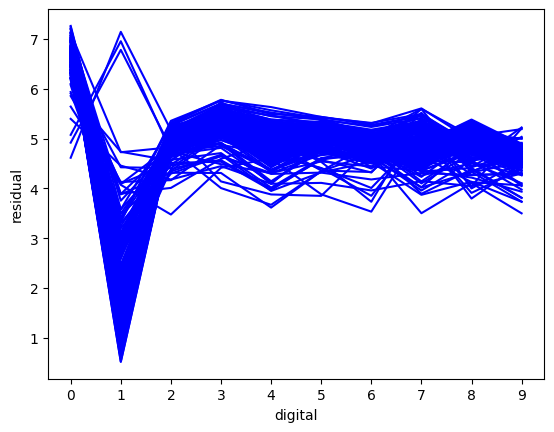

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_1.shape[0]):
    plt.plot(result_Test_1_residual[i],color = 'blue')

## Digit 0

In [ ]:
components = np.where(y_Test == 0)[0]
components
x_Test_0 = x_Test[components, :]
y_Test_0 = np.full(x_Test_0.shape[0],0)

x_Test_0_data = pd.concat([pd.DataFrame(x_Test_0),pd.DataFrame(y_Test_0, columns=['digital'])], axis=1)
result_Test_0_list, y_Test_0_predict, result_Test_0_residual = simpleAlgorithm(x_Test_0_data, x_Train_mean)

In [ ]:
y_Test_0_predict

0.8245125348189415

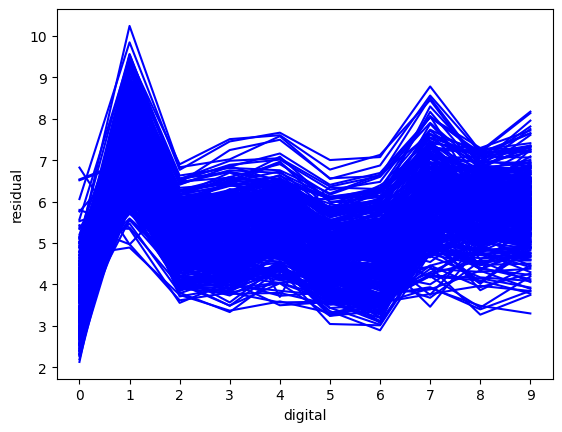

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_0.shape[0]):
  plt.plot(result_Test_0_residual[i],color = 'blue')

## Digit 2

In [ ]:
components = np.where(y_Test == 2)[0]
components
x_Test_2 = x_Test[components, :]
y_Test_2 = np.full(x_Test_2.shape[0],2)

x_Test_2_data = pd.concat([pd.DataFrame(x_Test_2),pd.DataFrame(y_Test_2, columns=['digital'])], axis=1)
result_Test_2_list, y_Test_2_predict, result_Test_2_residual = simpleAlgorithm(x_Test_2_data, x_Train_mean)

In [ ]:
y_Test_2_predict

0.6818181818181818

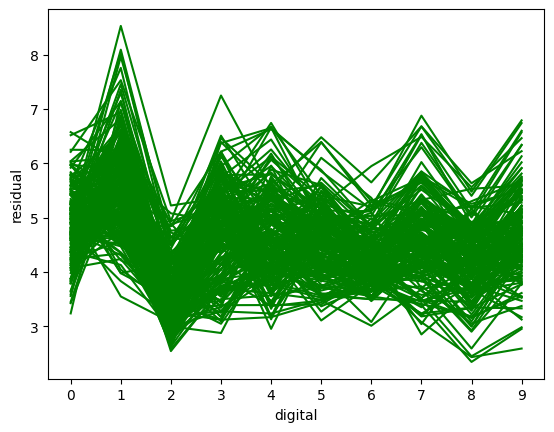

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_2.shape[0]):
    plt.plot(result_Test_2_residual[i],color = 'green')

## Digit 5

In [ ]:
components = np.where(y_Test == 5)[0]
components
x_Test_5 = x_Test[components, :]
y_Test_5 = np.full(x_Test_5.shape[0],5)

x_Test_5_data = pd.concat([pd.DataFrame(x_Test_5),pd.DataFrame(y_Test_5, columns=['digital'])], axis=1)
result_Test_5_list, y_Test_5_predict, result_Test_5_residual = simpleAlgorithm(x_Test_5_data, x_Train_mean)

In [ ]:
y_Test_5_predict

0.66875

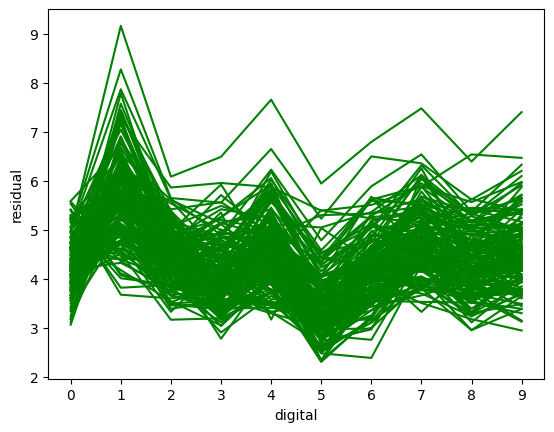

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_5.shape[0]):
    plt.plot(result_Test_5_residual[i],color = 'green')

## Predicted correctly between min and max 2-norm residual

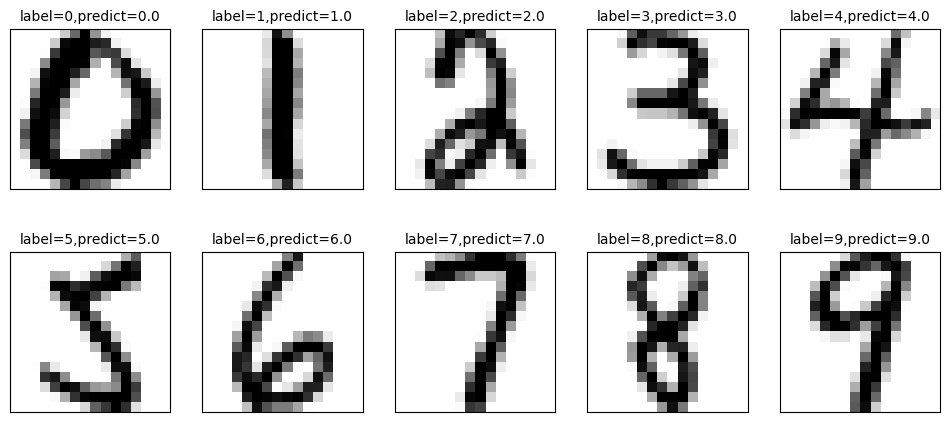

In [ ]:
minList = x_Test_Prediction[x_Test_Prediction['digital'] == x_Test_Prediction['prediction']].groupby('digital').agg({'residual': ['min']})
niceIndex = np.zeros(10)

for i in range(0,10):
  digitalList = x_Test_Prediction[x_Test_Prediction['digital'] == i]
  niceIndex[i] = int(digitalList[digitalList['residual'] == minList['residual']['min'][i]].index.values[0])

niceList = x_Test_Prediction.iloc[x_Test_Prediction.index.get_indexer(niceIndex)]
plot_images_labels_prediction(niceList.iloc[:,np.arange(0, 256)], niceList.iloc[:,[256]], niceList.iloc[:,[257]],0,10)

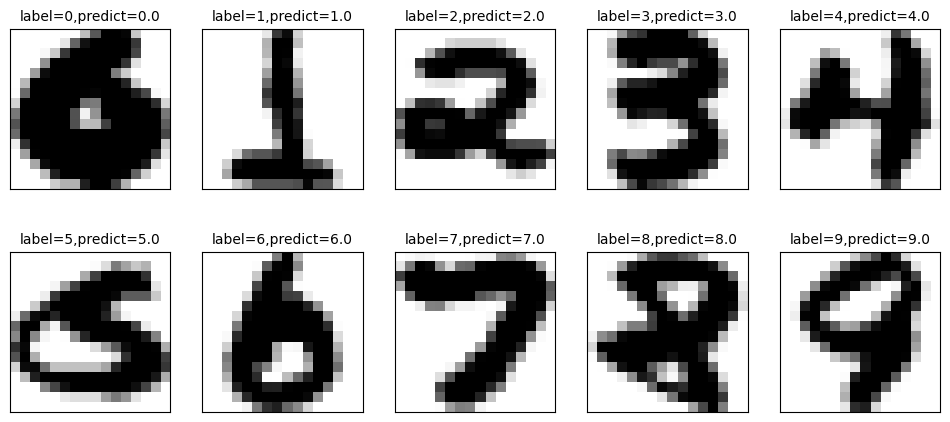

In [ ]:
maxList = x_Test_Prediction[x_Test_Prediction['digital'] == x_Test_Prediction['prediction']].groupby('digital').agg({'residual': ['max']})
uglyIndex = np.zeros(10)

for i in range(0,10):
    digitalList = x_Test_Prediction[x_Test_Prediction['digital'] == i]
    uglyIndex[i] = int(digitalList[digitalList['residual'] == maxList['residual']['max'][i]].index.values[0])

uglyList = x_Test_Prediction.iloc[x_Test_Prediction.index.get_indexer(uglyIndex)]
plot_images_labels_prediction(uglyList.iloc[:,np.arange(0, 256)], uglyList.iloc[:,[256]], uglyList.iloc[:,[257]],0,10)

## Test with my own data

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r")
  x_son1[i,:] = (np.array(img)/255).flatten()

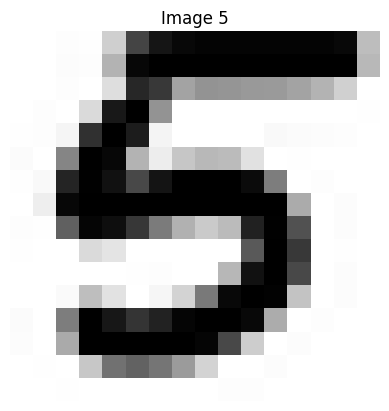

In [ ]:
# plt.imshow(img, cmap="gray")
plt.imshow(x_son1[5,:].reshape(16,16), cmap="binary")
plt.title(f"Image {5}")
plt.axis('off')
plt.show()

In [ ]:
x_son1_data = pd.concat([pd.DataFrame(x_son1),pd.DataFrame(y_son1, columns=['digital'])], axis=1)

In [ ]:
# @title
x_son1_data.iloc[0, 128:256]

In [ ]:
x_son1_Prediction, x_son1_result, result_son1_residual = simpleAlgorithm(x_son1_data, x_Train_mean)
x_son1_result

0.5

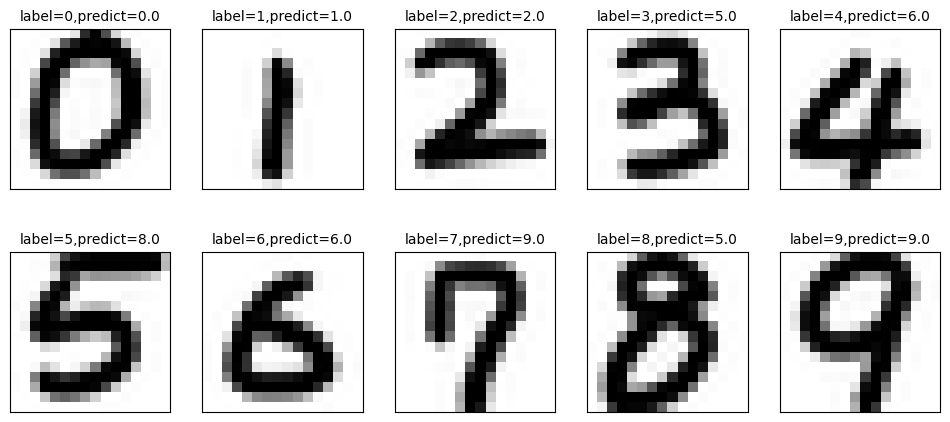

In [ ]:
plot_images_labels_prediction(x_son1_Prediction.iloc[:,np.arange(0, 256)], x_son1_Prediction.iloc[:,[256]], x_son1_Prediction.iloc[:,[257]],0,10)

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
  x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_data = pd.concat([pd.DataFrame(x_son2),pd.DataFrame(y_son2, columns=['digital'])], axis=1)

In [ ]:
x_son2_Prediction, x_son2_result, result_son2_residual = simpleAlgorithm(x_son2_data, x_Train_mean)
x_son2_result

0.6

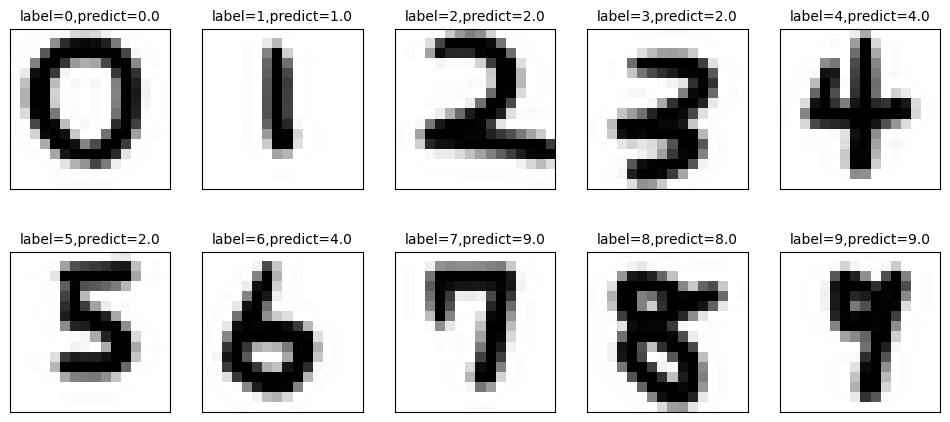

In [ ]:
plot_images_labels_prediction(x_son2_Prediction.iloc[:,np.arange(0, 256)], x_son2_Prediction.iloc[:,[256]], x_son2_Prediction.iloc[:,[257]],0,10)

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
  x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_data = pd.concat([pd.DataFrame(x_son3),pd.DataFrame(y_son3, columns=['digital'])], axis=1)

In [ ]:
x_son3_Prediction, x_son3_result, result_son3_residual = simpleAlgorithm(x_son3_data, x_Train_mean)
x_son3_result

0.1

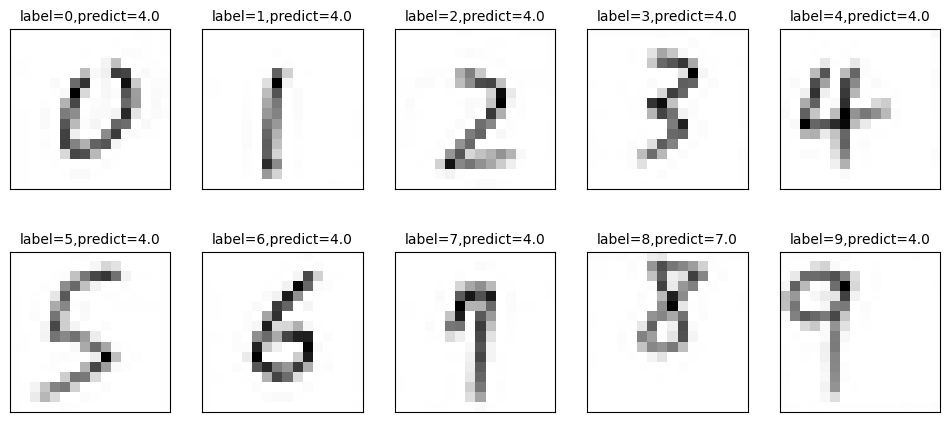

In [ ]:
plot_images_labels_prediction(x_son3_Prediction.iloc[:,np.arange(0, 256)], x_son3_Prediction.iloc[:,[256]], x_son3_Prediction.iloc[:,[257]],0,10)

In [ ]:
# @title
# Record all the results
overall_pred_res("Mean", [x_Test_result, x_son1_result, x_son2_result])

# Classification Using SVD Bases

In [ ]:
def getUList(x_Data, y_Data):
  # We now normalize all values between 0 and 1 and we now flatten the 16 × 16 images into vectors of size 256.

  x_Data = x_Data.astype('float32') / 255 if x_Data.max() > 1 else x_Data.astype('float32')
  x_Data = x_Data.reshape((len(x_Data), np.prod(x_Data.shape[1:])))
  x_Data = x_Data.T

  #  we now partition the x_train based on the ten classes and store in a list.
  x_list = []

  for k in range(10):
    components = np.where(y_Data == k)[0]
    x_list.append(x_Data[:, components])

  # we now create a svd basis for each digit data samples.
  U_list = []

  for k in range(10):
    U, S, V = np.linalg.svd(x_list[k])
    U_list.append(U)

  return U_list


def svdAlgorithm (x_Data, y_Data, U_list,basis):
  # We now normalize all values between 0 and 1 and we now flatten the 16 × 16 images into vectors of size 256.
  x_Data = x_Data.astype('float32') / 255 if x_Data.max() > 1 else x_Data.astype('float32')
  x_Data = x_Data.reshape((len(x_Data), np.prod(x_Data.shape[1:])))
  x_Data = x_Data.T

  # we now select the dominant orthogonal basis and project the digits on the reduced basis to compute the least square projection error.
  result_mse = []
  result_residual = []

  for r in range(basis):
    n_Data = x_Data.shape[1]
    y_predict = np.ones(n_Data)
    result_single = np.ones(n_Data)

    for i in range(0, n_Data):
      z = x_Data[:, i]
      residual_list = np.ones(10)

      for j in range(10):
        U_k = U_list[j][:, :r+1]
        # residual = np.linalg.norm(z - np.dot(U_k, np.dot(U_k.T, z)),2)/np.linalg.norm(z,2)
        residual = np.linalg.norm(z - U_k @ (U_k.T @ z),2)/np.linalg.norm(z,2)
        residual_list[j] = residual

      y_predict[i] = np.argmin(residual_list)

      if r == basis-1:
        result_residual.append(residual_list)
        result_single[i] = np.amin(residual_list)

    result_mse.append(np.mean((y_Data/1.0 - y_predict/1.0) ** 2))

  x_Data_list = pd.concat([pd.DataFrame(x_Data.T),pd.DataFrame(y_Data, columns=['actual'])], axis=1)
  result_List = pd.concat([x_Data_list, pd.DataFrame(y_predict, columns=['prediction'])], axis=1)
  result_List = pd.concat([result_List, pd.DataFrame(result_single, columns=['residual'])], axis=1)

  result_predict = result_List[result_List['actual'] == result_List['prediction']].shape[0]/result_List.shape[0]

  return result_List, y_predict, result_predict, result_residual, result_mse

In [ ]:
# @title
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
U_list = getUList(x_Train, y_Train)

In [ ]:
U_list[0].shape, len(U_list)

((256, 256), 10)

In [ ]:
def find_best_k(U_list, x_val, y_val, max_k=50):
    """
    自動 reshape + 自動處理 USPS SVD 子空間分類器的最佳 k 搜尋
    x_val: 可以是 (N, 256) 或 (256, N) 或 (N, 16, 16)
    y_val: shape = (N,)
    """

    # --- Step 1: 自動 reshape x_val 成 (256, N) ---
    if x_val.ndim == 3:  # (N, 16, 16)
        x_val = x_val.reshape(len(x_val), -1).T
    elif x_val.shape[0] != 256 and x_val.shape[1] == 256:
        x_val = x_val.T
    elif x_val.shape[0] != 256 and x_val.shape[1] != 256:
        raise ValueError("x_val 無法 reshape 成 256 維影像，請確認資料格式")

    # 現在 x_val shape = (256, N)
    N = x_val.shape[1]

    # --- Step 2: y_val reshape ---
    y_val = np.array(y_val).reshape(-1)
    if len(y_val) != N:
        raise ValueError("x_val 與 y_val 的樣本數不一致")

    # --- Step 3: 搜尋最佳 k ---
    best_k = None
    best_acc = 0

    for k in range(1, max_k + 1):
        correct = 0

        for i in range(N):
            x = x_val[:, i]

            residuals = []
            for d in range(10):
                U = U_list[d][:, :k]  # (256, k)
                x_hat = U @ (U.T @ x)  # (256,)
                residuals.append(np.linalg.norm(x - x_hat))

            pred = np.argmin(residuals)
            if pred == y_val[i]:
                correct += 1

        acc = correct / N

        if acc > best_acc:
            best_acc = acc
            best_k = k

    return best_k, best_acc

In [ ]:
from sklearn.model_selection import train_test_split

x_train2, x_val, y_train2, y_val = train_test_split(
    x_Train, y_Train, test_size=0.2, random_state=42, stratify=y_Train
)
U_list2 = getUList(x_train2, y_train2)
best_k, best_acc = find_best_k(U_list2, x_val, y_val)
best_k, best_acc

(18, 0.978067169294037)

In [ ]:
# @title
best_k, best_acc = find_best_k(U_list, x_Train, y_Train)
best_k, best_acc

(37, 0.984638595528734)

In [ ]:
# Train dataset
result_Train_list, y_Train_predict, result_Train_predict, result_Train_residual, result_Train_mse = svdAlgorithm(x_Train, y_Train, U_list, 18) # K=18

In [ ]:
result_Train_predict

0.9792895350432039

In [ ]:
result_Train_mse

[np.float64(3.198052393361679),
 np.float64(1.4978740913454944),
 np.float64(1.2891235770127554),
 np.float64(0.9462350843505692),
 np.float64(0.7939925936085585),
 np.float64(0.7944040597997531),
 np.float64(0.7104649567960499),
 np.float64(0.5841448360993005),
 np.float64(0.5739953367164998),
 np.float64(0.5336716499794267),
 np.float64(0.5542449595391579),
 np.float64(0.5044575504046084),
 np.float64(0.437114250445755),
 np.float64(0.41036894801810453),
 np.float64(0.36113016047181457),
 np.float64(0.37950898367850777),
 np.float64(0.37415992319297764),
 np.float64(0.35948429570703605)]

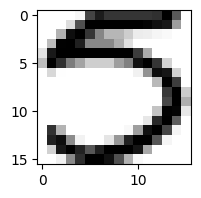

In [ ]:
plot_image(x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 256)].values[0].reshape([16, 16]))
# plot_image(x_Test_data.iloc[2, np.arange(0, 256)].values.reshape([16, 16]))
z = x_Test_data[x_Test_data['digital'] == 5].loc[:,np.arange(0, 256)].iloc[0].values
# z = x_Test_data.iloc[2, np.arange(0, 256)]

In [ ]:
# @title
type(U_list), len(U_list[5])

(list, 256)

k=18

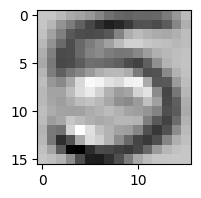

np.float32(0.44346413)

In [ ]:
U_k = U_list[5][:, :18]
plot_image(np.dot(U_k, np.dot(U_k.T, z)).reshape([16, 16]))
residual = np.linalg.norm(z - U_k @ (U_k.T @ z),2)/np.linalg.norm(z,2)
residual

k=1

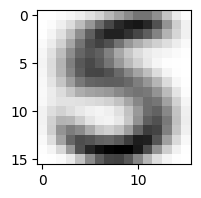

np.float32(0.7366781)

In [ ]:
U_k = U_list[5][:, :1]
plot_image((U_k @ (U_k.T @ z)).reshape([16, 16]))
residual = np.linalg.norm(z - U_k @ (U_k.T @ z),2)/np.linalg.norm(z,2)
residual

Residual of Z=5 and digit=0-9(k=10)

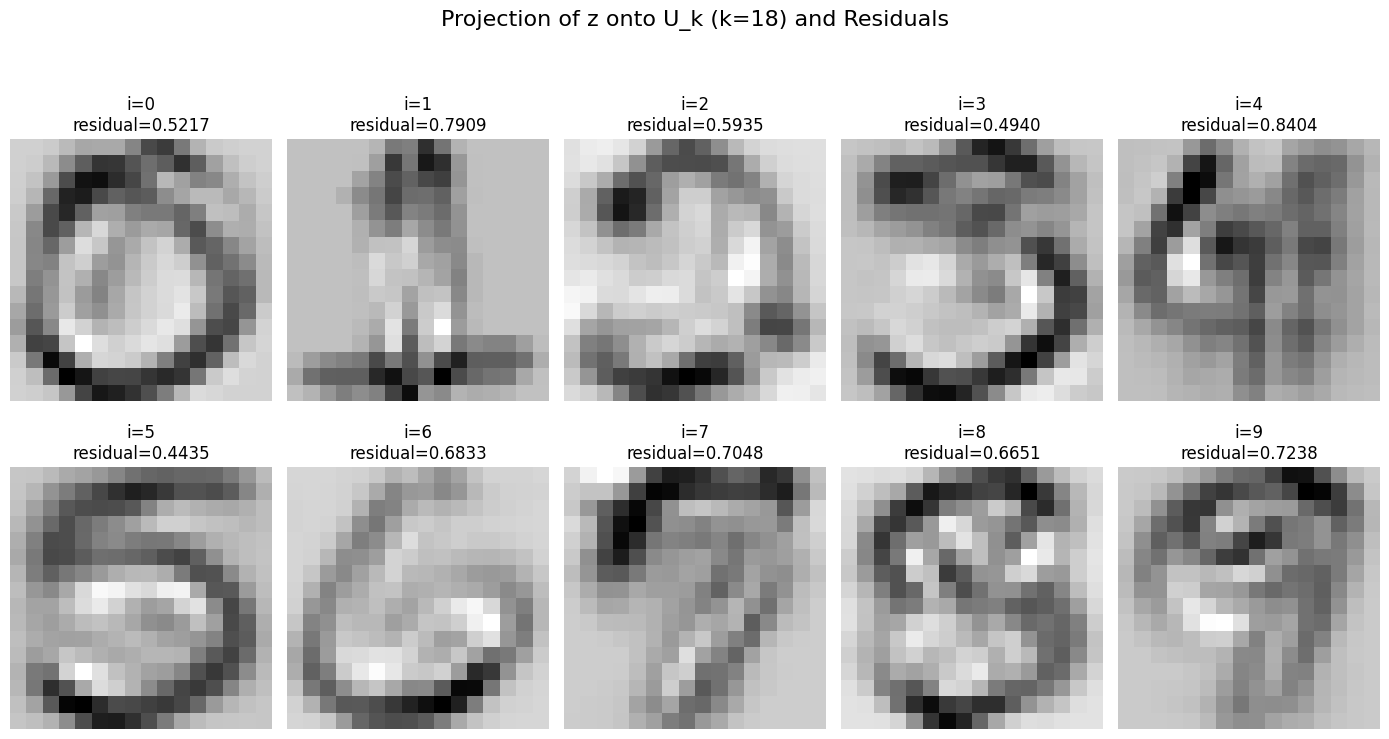

In [ ]:
k = 18
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle(f"Projection of z onto U_k (k={k}) and Residuals", fontsize=16)

for i in range(10):
  U_k = U_list[i][:, :k]  # 取前 k 個主成分
  z_proj = U_k @ (U_k.T @ z) # 投影到子空間再投影回原空間
  residual = np.linalg.norm(z - z_proj) / np.linalg.norm(z)

  ax = axes[i // 5, i % 5]
  ax.imshow(z_proj.reshape(16, 16), cmap='binary')
  ax.set_title(f"i={i}\nresidual={residual:.4f}")
  ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Residual of Z=5 and digit=0-9(k=1)

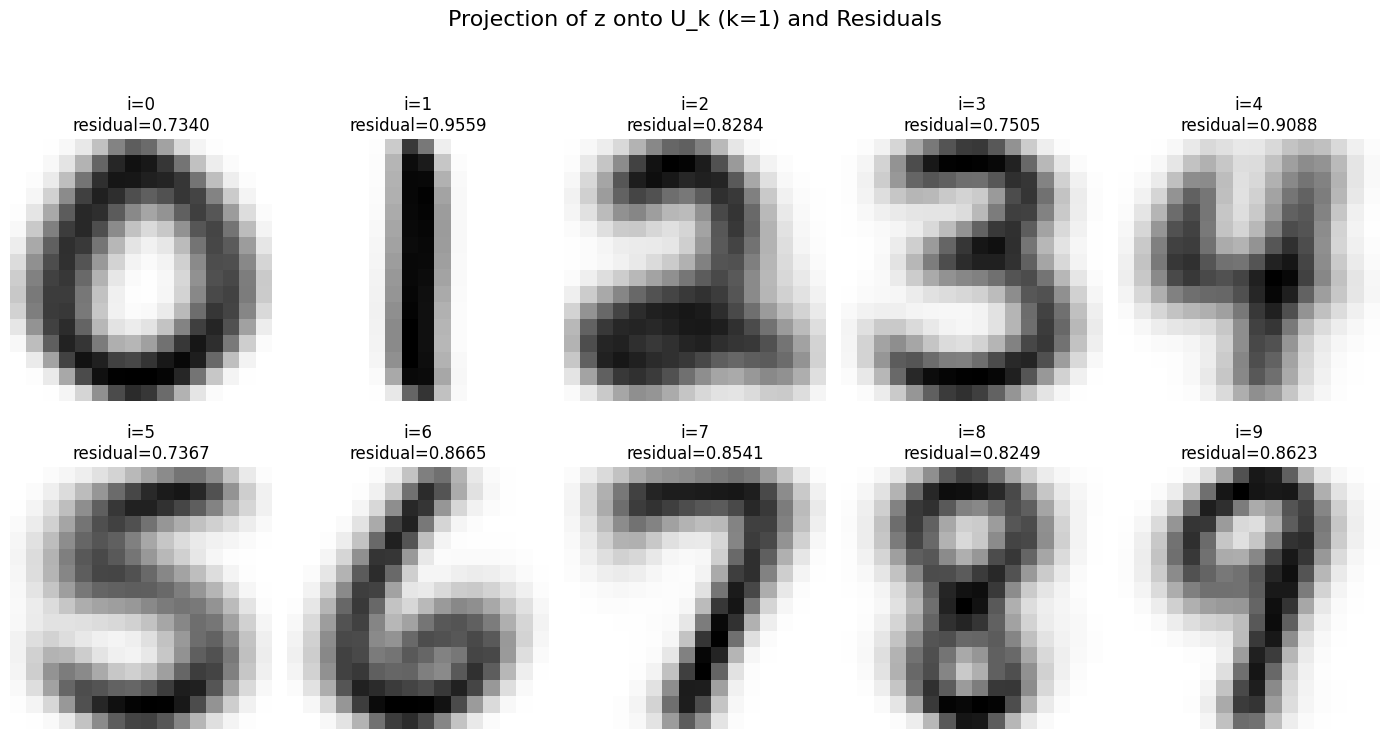

In [ ]:
k = 1
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle(f"Projection of z onto U_k (k={k}) and Residuals", fontsize=16)

for i in range(10):
  U_k = U_list[i][:, :k]  # 取前 k 個主成分
  z_proj = U_k @ (U_k.T @ z)  # 投影到子空間再投影回原空間
  residual = np.linalg.norm(z - z_proj) / np.linalg.norm(z)

  ax = axes[i // 5, i % 5]
  ax.imshow(z_proj.reshape(16, 16), cmap='binary')
  ax.set_title(f"i={i}\nresidual={residual:.4f}")
  ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

Residual of Z=5 and digit=0-9(k=30)

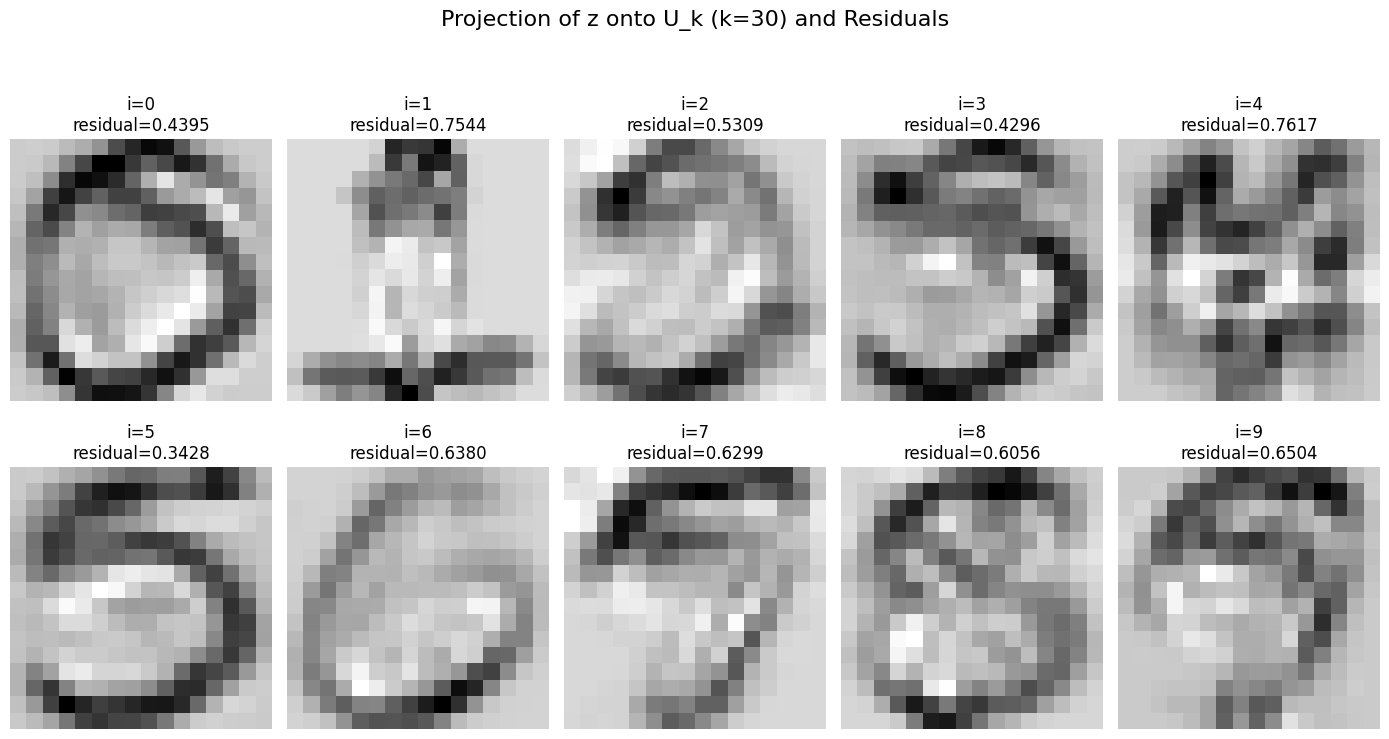

In [ ]:
k = 30
fig, axes = plt.subplots(2, 5, figsize=(14, 8))
fig.suptitle(f"Projection of z onto U_k (k={k}) and Residuals", fontsize=16)

for i in range(10):
  U_k = U_list[i][:, :k]  # 取前 k 個主成分
  # z_proj = np.dot(U_k, np.dot(U_k.T, z))  # 投影到子空間再投影回原空間
  z_proj = U_k @ (U_k.T @ z)
  residual = np.linalg.norm(z - z_proj) / np.linalg.norm(z)

  ax = axes[i // 5, i % 5]
  ax.imshow(z_proj.reshape(16, 16), cmap='binary')
  ax.set_title(f"i={i}\nresidual={residual:.4f}")
  ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

In [ ]:
result_Train_list[result_Train_list['prediction'] != result_Train_list['actual']].shape[0]

151

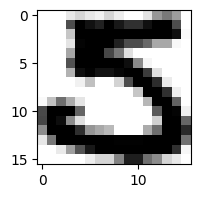

In [ ]:
img = x_Train[y_Train == 5][0]
plot_image(img.reshape([16, 16]))

In [ ]:
# result_Train_residual[7290]
result_Train_residual[np.where(y_Train == 5)[0][0]]

array([0.50147265, 0.73129183, 0.54163861, 0.40989456, 0.70121616,
       0.28714582, 0.5960691 , 0.71456778, 0.57101989, 0.69917393])

Text(0.5, 0, 'number of basis')

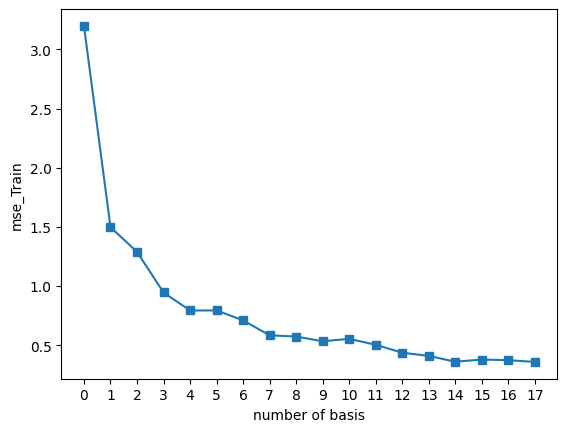

In [ ]:
plt.plot(result_Train_mse,'s-')
plt.xticks(range(0,18))
plt.ylabel('mse_Train')
plt.xlabel('number of basis')

In [ ]:
# Test dataset
result_Test_list, y_Test_predict, result_Test_predict, result_Test_residual, result_Test_mse = svdAlgorithm(x_Test, y_Test, U_list, 18)

In [ ]:
result_Test_predict

0.9407075236671649

In [ ]:
result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']].shape[0]

119

Predict wrong

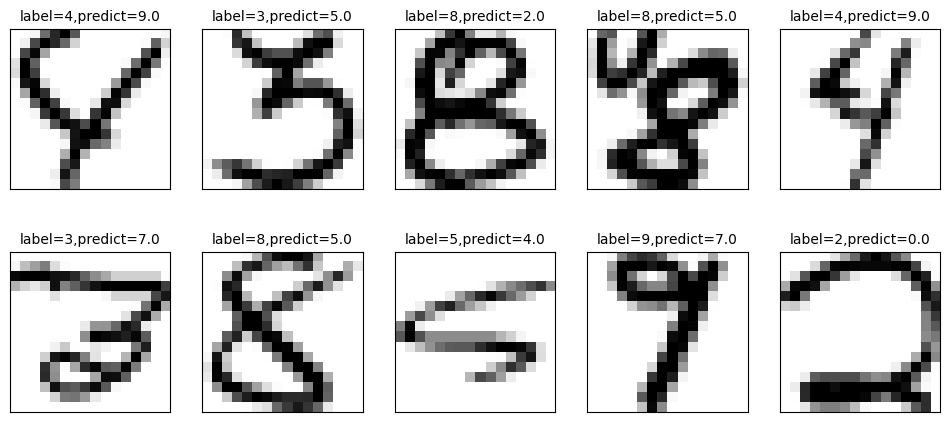

In [ ]:
errorList = result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']]

errorList.shape

plot_images_labels_prediction(errorList.iloc[:,np.arange(0, 256)], errorList.iloc[:,[256]], errorList.iloc[:,[257]],0,10)

In [ ]:
# 計算每個 (digital, prediction) 的錯誤次數
temp = (
    errorList[['actual', 'prediction']]
    .groupby(['actual', 'prediction'])
    .size()
    .reset_index(name='counts')
)

# 建立空的錯誤預測矩陣：4 × 10
errorPrediction = np.zeros((4, 10))

# 對每個真實數字 i，找出最常見的兩個錯誤預測
for i in range(10):
  top_errors = (
      temp[temp['actual'] == i]
      .sort_values('counts', ascending=False)
      .head(2)
  )
  if len(top_errors) > 0:
      errorPrediction[0][i] = top_errors.iloc[0]['prediction']
      errorPrediction[1][i] = top_errors.iloc[0]['counts']
  if len(top_errors) > 1:
      errorPrediction[2][i] = top_errors.iloc[1]['prediction']
      errorPrediction[3][i] = top_errors.iloc[1]['counts']

# 包裝成 DataFrame
error_df = pd.DataFrame(errorPrediction, columns=np.arange(10))
error_df.index = ["1st wrongly predicted digit", "Qty", "2nd wrongly predicted digit", "Qty"]
error_df

,0,1,2,3,4,5,6,7,8,9
1st wrongly predicted digit,1.0,4.0,0.0,5.0,9.0,0.0,5.0,4.0,3.0,4.0
Qty,2.0,3.0,9.0,11.0,6.0,5.0,2.0,3.0,4.0,4.0
2nd wrongly predicted digit,2.0,6.0,4.0,2.0,1.0,3.0,2.0,1.0,0.0,1.0
Qty,1.0,2.0,4.0,3.0,3.0,3.0,1.0,1.0,3.0,3.0


In [ ]:
# 計算每個數字的總預測數
totalCounts = result_Test_list['actual'].value_counts().sort_index().rename('totalCounts')

# 計算每個數字的錯誤數
errorCounts = errorList['actual'].value_counts().sort_index().rename('errorCounts')

# 合併成一個 DataFrame，缺失值填 0
resultdf = pd.concat([totalCounts, errorCounts], axis=1).fillna(0)

# 計算成功數與成功率
resultdf['errorCounts'] = resultdf['errorCounts'].astype(int)
resultdf['successCounts'] = resultdf['totalCounts'] - resultdf['errorCounts']
resultdf['probability'] = resultdf['successCounts'] / resultdf['totalCounts']

# 依成功率排序
resultdf = resultdf.sort_values('probability', ascending=False).reset_index()
resultdf

,actual,totalCounts,errorCounts,successCounts,probability
0,0,359,5,354,0.986072
1,1,264,5,259,0.981061
2,6,170,4,166,0.976471
3,7,147,6,141,0.959184
4,9,177,11,166,0.937853
5,4,200,17,183,0.915000
6,8,166,15,151,0.909639
7,2,198,19,179,0.904040
8,5,160,16,144,0.900000
9,3,166,21,145,0.873494


Predict correctly with min residual

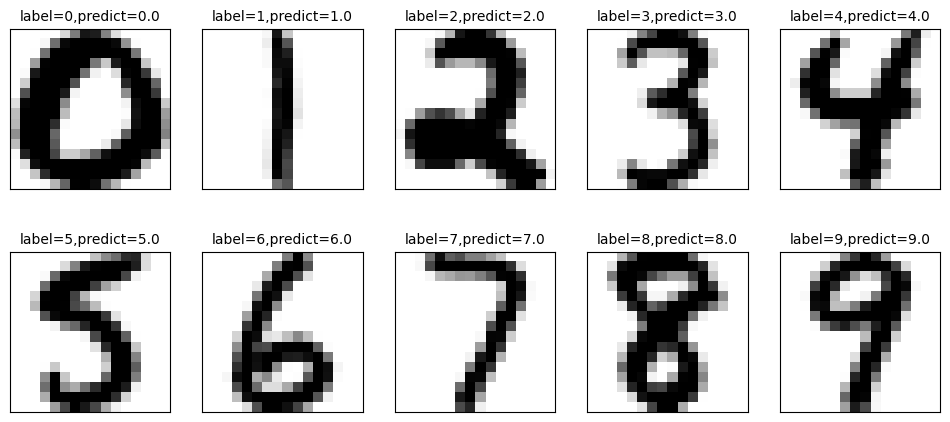

In [ ]:
minList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['min']})


niceIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    niceIndex[i] = int(digitalList[digitalList['residual'] == minList['residual']['min'][i]].index.values[0])

niceList = result_Test_list.iloc[result_Test_list.index.get_indexer(niceIndex)]

plot_images_labels_prediction(niceList.iloc[:,np.arange(0, 256)], niceList.iloc[:,[256]], niceList.iloc[:,[257]],0,10)

Predict correctly with max residual

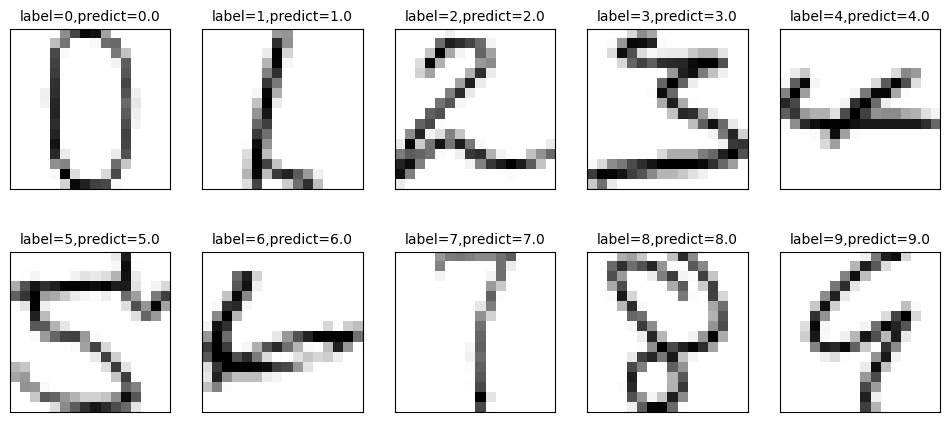

In [ ]:
maxList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['max']})

uglyIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    uglyIndex[i] = int(digitalList[digitalList['residual'] == maxList['residual']['max'][i]].index.values[0])

uglyList = result_Test_list.iloc[result_Test_list.index.get_indexer(uglyIndex)]

plot_images_labels_prediction(uglyList.iloc[:,np.arange(0, 256)], uglyList.iloc[:,[256]], uglyList.iloc[:,[257]],0,10)

In [ ]:
result_Test_residual[np.where(y_Test == 5)[0][0]]

array([0.5216729 , 0.79088104, 0.59352791, 0.49404386, 0.84044582,
       0.44346413, 0.68325794, 0.70479375, 0.66513962, 0.72376841])

Text(0.5, 0, 'number of basis')

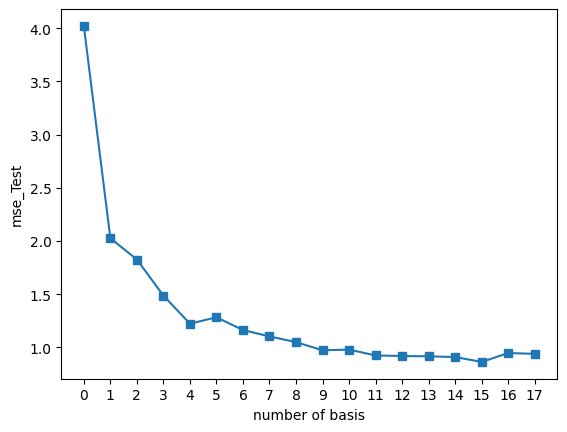

In [ ]:
plt.plot(result_Test_mse,'s-')
plt.xticks(range(0,18))
plt.ylabel('mse_Test')
plt.xlabel('number of basis')

Digit 0

In [ ]:
components = np.where(y_Test == 0)[0]
components
x_Test_0 = x_Test[components, :]
y_Test_0 = np.full(x_Test_0.shape[0],0)

In [ ]:
result_Test_0_list, y_Test_0_predict, result_Test_0_predict, result_Test_0_residual, result_Test_0_mse = svdAlgorithm(x_Test_0, y_Test_0, U_list, 18)

In [ ]:
result_Test_0_predict

0.9860724233983287

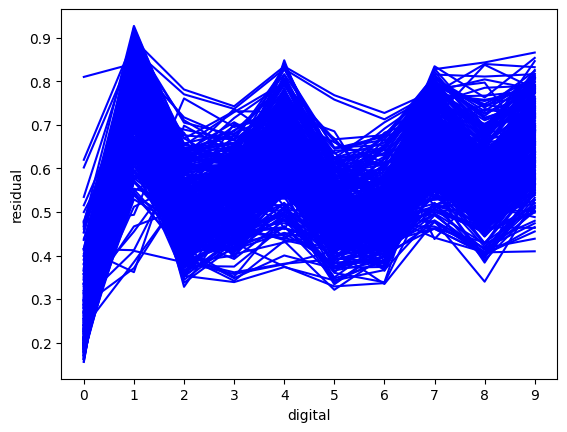

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_0.shape[0]):
    plt.plot(result_Test_0_residual[i],color = 'blue')

Digit 1

In [ ]:
components = np.where(y_Test == 1)[0]
components
x_Test_1 = x_Test[components, :]
y_Test_1 = np.full(x_Test_1.shape[0],1)

In [ ]:
result_Test_1_list, y_Test_1_predict, result_Test_1_predict, result_Test_1_residual, result_Test_1_mse = svdAlgorithm(x_Test_1, y_Test_1, U_list, 18)

In [ ]:
result_Test_1_predict

0.9810606060606061

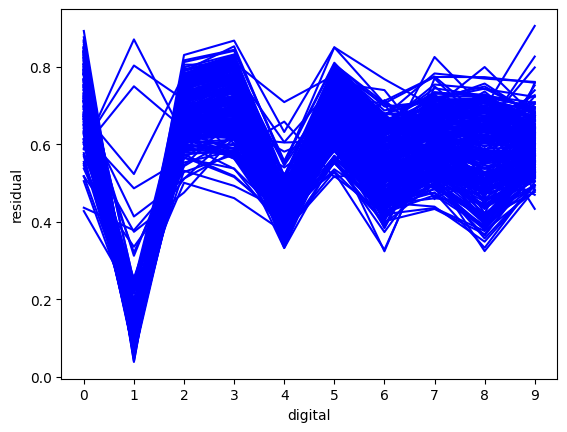

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_1.shape[0]):
    plt.plot(result_Test_1_residual[i],color = 'blue')

Digit 5

In [ ]:
components = np.where(y_Test == 5)[0]
components
x_Test_5 = x_Test[components, :]
y_Test_5 = np.full(x_Test_5.shape[0],5)

In [ ]:
result_Test_5_list, y_Test_5_predict, result_Test_5_predict, result_Test_5_residual, result_Test_5_mse = svdAlgorithm(x_Test_5, y_Test_5, U_list, 18)

In [ ]:
result_Test_5_predict

0.9

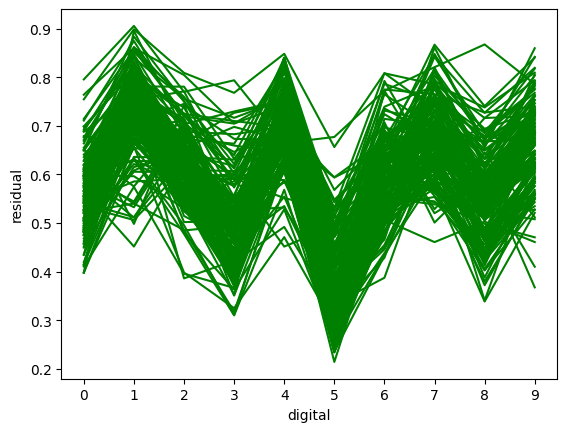

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_5.shape[0]):
    plt.plot(result_Test_5_residual[i],color = 'green')

Digit 3

In [ ]:
components = np.where(y_Test == 3)[0]
components
x_Test_3 = x_Test[components, :]
y_Test_3 = np.full(x_Test_3.shape[0],3)

In [ ]:
result_Test_3_list, y_Test_3_predict, result_Test_3_predict, result_Test_3_residual, result_Test_3_mse = svdAlgorithm(x_Test_3, y_Test_3, U_list, 18)

In [ ]:
result_Test_3_predict

0.8734939759036144

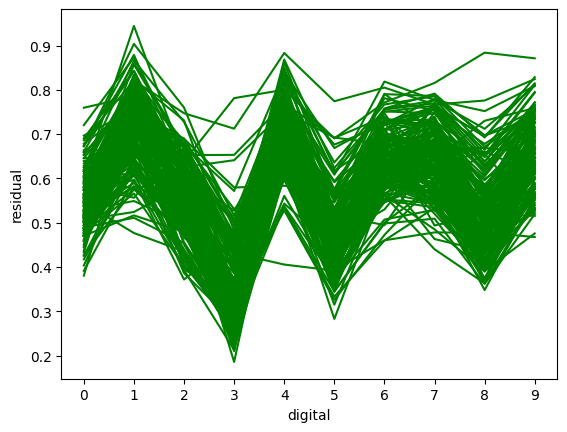

In [ ]:
plt.xticks(range(0,10))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_3.shape[0]):
    plt.plot(result_Test_3_residual[i], color = 'green')

My own data

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son1_list, y_son1_predict, result_son1_predict, result_son1_residual, result_son1_mse = svdAlgorithm(x_son1, y_son1, U_list, 18)
result_son1_predict

0.9

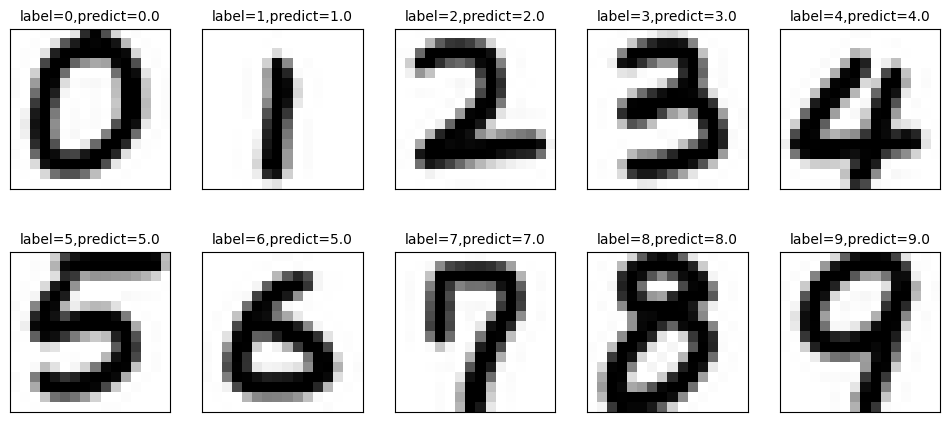

In [ ]:
plot_images_labels_prediction(result_son1_list.iloc[:,np.arange(0, 256)], result_son1_list.iloc[:,[256]], result_son1_list.iloc[:,[257]],0,10)

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
  x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son2_list, y_son2_predict, result_son2_predict, result_son2_residual, result_son2_mse = svdAlgorithm(x_son2, y_son2, U_list, 18)
result_son2_predict

0.6

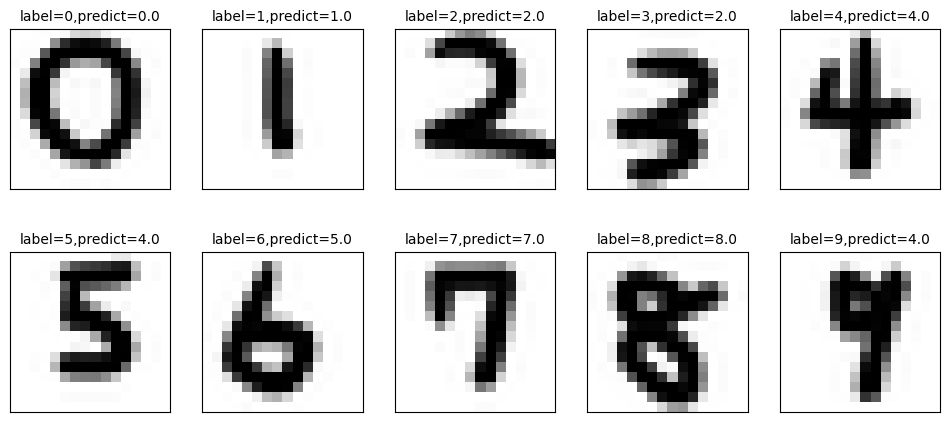

In [ ]:
plot_images_labels_prediction(result_son2_list.iloc[:,np.arange(0, 256)], result_son2_list.iloc[:,[256]], result_son2_list.iloc[:,[257]],0,10)

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
  x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son3_list, y_son3_predict, result_son3_predict, result_son3_residual, result_son3_mse = svdAlgorithm(x_son3, y_son3, U_list, 18)
result_son3_predict

0.4

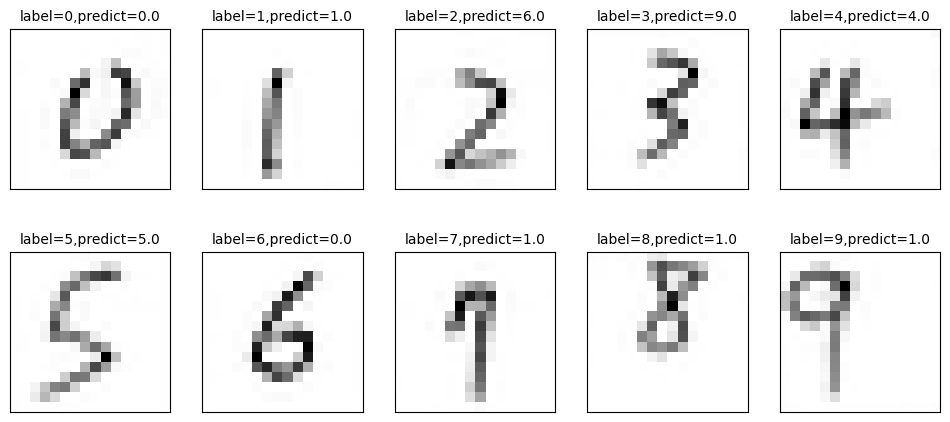

In [ ]:
plot_images_labels_prediction(result_son3_list.iloc[:,np.arange(0, 256)], result_son3_list.iloc[:,[256]], result_son3_list.iloc[:,[257]],0,10)

In [ ]:
# @title
# Record all the results
overall_pred_res("SVD", [result_Test_predict, result_son1_predict, result_son2_predict])

# Classification Using higher order SVD (HOSVD)

In [ ]:
!pip install tensorly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 58.3 MB/s eta 0:00:00


In [ ]:
# @title
!pip install --upgrade tensorly

In [ ]:
import numpy as np
import pandas as pd
import tensorly as tl
from tensorly.decomposition import tucker

tl.set_backend('numpy')  # 可改為 'pytorch' 或 'tensorflow'

def getSandUList(x_Train, y_Train, img_shape=(16, 16), ranks=(16, 16, 10)):
    x_list = [x_Train[np.where(y_Train == k)[0]] for k in range(10)]

    S_list = []
    U_list = []

    for k in range(10):
        tensor = np.zeros((img_shape[0], img_shape[1], x_list[k].shape[0]))
        for i in range(x_list[k].shape[0]):
            tensor[:, :, i] = x_list[k][i].reshape(img_shape)

        # 使用 tensorly 的 Tucker 分解
        core, factors = tucker(tensor, tensor.shape) #(ranks))
        S_list.append(core)
        U_list.append(factors[:3])  # 保留 U1, U2, U3（空間維度）

    return S_list, U_list

def hosvdAlgorithm(x_Data, y_Data, S_list, U_list, basis, img_shape=(16, 16)):
    x_Data = x_Data.astype('float32') / 255 if x_Data.max() > 1 else x_Data.astype('float32')
    x_Data = x_Data.reshape((len(x_Data), np.prod(x_Data.shape[1:])))

    result_mse = []
    result_residual = []

    for r in range(basis):
        n_Data = x_Data.shape[0]
        y_predict = np.ones(n_Data)
        result_single = np.ones(n_Data)

        for i in range(n_Data):
            Z = x_Data[i].reshape(img_shape)
            residual_list = np.ones(10)

            for d in range(10):
                U1, U2, U3 = U_list[d]
                S = S_list[d]

                Sigma = np.zeros(img_shape)

                for j in range(r + 1):
                  if j < S.shape[2]:
                    Aj = U1 @ S[:, :, j] @ U2.T
                    Zj = np.tensordot(Z, Aj) / np.tensordot(Aj, Aj)
                    Sigma += Zj * Aj

                G = np.linalg.norm(Z - Sigma, "fro")
                residual_list[d] = G

            y_predict[i] = np.argmin(residual_list)

            if r == basis - 1:
                result_residual.append(residual_list)
                result_single[i] = np.min(residual_list)

        result_mse.append(np.mean((y_Data - y_predict) ** 2))

    x_Data_list = pd.concat([pd.DataFrame(x_Data), pd.DataFrame(y_Data, columns=['actual'])], axis=1)
    result_list = pd.concat([x_Data_list, pd.DataFrame(y_predict, columns=['prediction'])], axis=1)
    result_list = pd.concat([result_list, pd.DataFrame(result_single, columns=['residual'])], axis=1)
    result_prediction = (result_list['prediction'] == result_list['actual']).mean()

    return result_list, y_predict, result_prediction, result_residual, result_mse

In [ ]:
# @title
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

Use digit=5 for trial

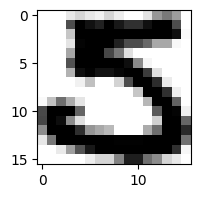

In [ ]:
plot_image(x_Train[y_Train == 5][0].reshape([16, 16]))

In [ ]:
components = np.where(y_Train == 5)[0]
components
x_Train_5 = x_Train[components, :]
y_Train_5 = np.full(x_Train_5.shape[0],5)

x_Train_5.shape

(556, 256)

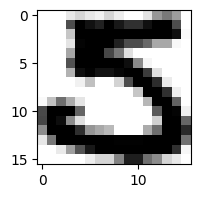

In [ ]:
tensor = np.zeros((16, 16, x_Train_5.shape[0]))

for i in range(x_Train_5.shape[0]):
    tensor[:,:,i] = x_Train_5[i][:].reshape([16, 16])

plot_image(tensor[:,:,0])

In [ ]:
# 使用 tensorly 進行 Tucker 分解
k=18
# core, factors = tucker(tensor, (16, 16, k), init='svd')
core, factors = tucker(tensor, tensor.shape, init='svd')

# core 對應原本的 S，factors 對應原本的 U（U1, U2, U3）
S = core
U = factors

In [ ]:
S.shape, U[0].shape, U[1].shape, U[2].shape

((16, 16, 556), (16, 16), (16, 16), (556, 556))

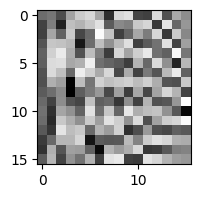

In [ ]:
plot_image(U[0])

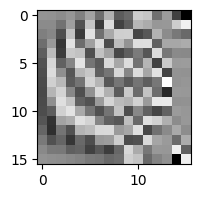

In [ ]:
plot_image(U[1])

In [ ]:
# @title
plot_image(U[2])

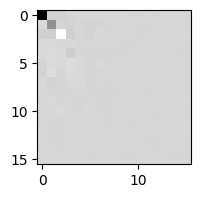

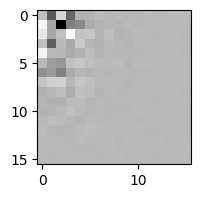

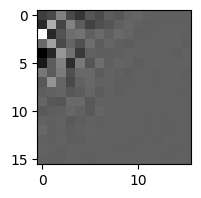

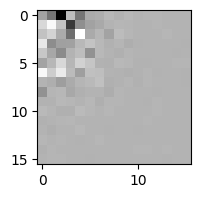

In [ ]:
plot_image(S[:,:,0])
plot_image(S[:,:,1])
plot_image(S[:,:,2])
plot_image(S[:,:,3])

hosvd_tensor vs ori tensor

$$
A_{\mathrm{hosvd}} = S \times_{1} U[0] \times_{2} U[1] \times_{3} U[2]
$$

In [ ]:
import torch as tc

A_hosvd = tc.einsum("abc,da,eb,fc->def", tc.as_tensor(S), tc.as_tensor(U[0]), tc.as_tensor(U[1]), tc.as_tensor(U[2]))

In [ ]:
hosvd_tensor = tc.Tensor.cpu(A_hosvd).detach().numpy()[:,:,:]

In [ ]:
tensor.shape, hosvd_tensor.shape

((16, 16, 556), (16, 16, 556))

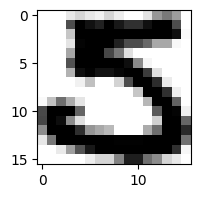

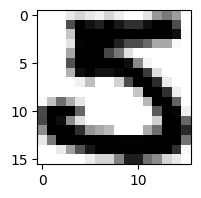

In [ ]:
plot_image(tensor[:,:,0])
plot_image(hosvd_tensor[:,:,0])

In [ ]:
error = np.linalg.norm(tensor - hosvd_tensor)
error

np.float64(4.0696188333640663e-13)

In [ ]:
relative_error = error / np.linalg.norm(tensor)
relative_error

np.float64(2.2007961976072674e-15)

In [ ]:
# @title
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


Train dataset

In [ ]:
S_list, U_list = getSandUList(x_Train, y_Train)

In [ ]:
U1, U2, U3 = U_list[5]
S = S_list[5]
S.shape, U1.shape, U2.shape, U3.shape

((16, 16, 556), (16, 16), (16, 16), (556, 556))

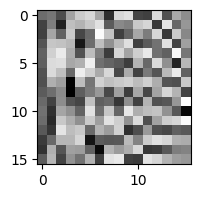

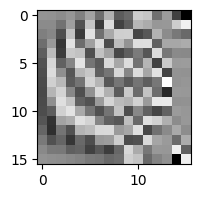

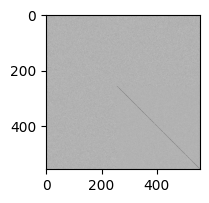

In [ ]:
plot_image(U1)
plot_image(U2)
plot_image(U3)

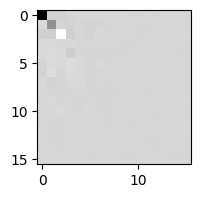

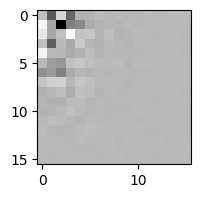

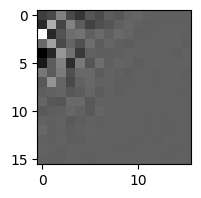

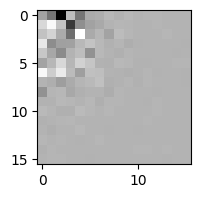

In [ ]:
plot_image(S[:,:,0])
plot_image(S[:,:,1])
plot_image(S[:,:,2])
plot_image(S[:,:,3])

slice=0

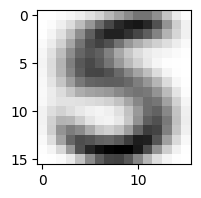

In [ ]:
Aj = U1.dot(S[:,:,0]).dot(U2.T)
plot_image(Aj)

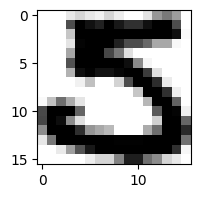

In [ ]:
Z = x_Train[y_Train == 5][0].reshape([16, 16])
plot_image(Z)

In [ ]:
 Zj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj)
 Zj

np.float64(0.05725218657406411)

In [ ]:
G = np.linalg.norm(Z-Zj*Aj,"fro")
G

np.float64(5.639806433506592)

In [ ]:
U1, U2, U3 = U_list[5]
S = S_list[5]
S.shape, U1.shape, U2.shape, U3.shape

((16, 16, 556), (16, 16), (16, 16), (556, 556))

slice=18

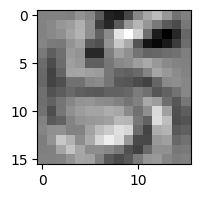

In [ ]:
Aj = U1.dot(S[:,:,17]).dot(U2.T)
plot_image(Aj)

In [ ]:
 Zj = np.tensordot(Z, Aj)/np.tensordot(Aj, Aj)
 Zj

np.float64(0.029760720063629724)

In [ ]:
G = np.linalg.norm(Z-Zj*Aj, "fro")
G

np.float64(9.92928502238039)

In [ ]:
# Train dataset
result_Train_list, y_Train_predict, result_Train_predict, result_Train_residual, result_Train_mse = hosvdAlgorithm(x_Train, y_Train, S_list, U_list, 18)

In [ ]:
result_Train_predict

np.float64(0.9792895350432039)

In [ ]:
# result_Train_residual[7290]
result_Train_residual[np.where(y_Train == 5)[0][0]]

array([4.98344558, 7.26730206, 5.38259985, 4.07337713, 6.96842162,
       2.85354672, 5.92350965, 7.10110456, 5.67457964, 6.94812641])

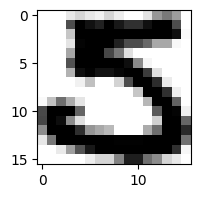

In [ ]:
plot_image(x_Train[np.where(y_Train == 5)[0][0]].reshape([16, 16]))

In [ ]:
result_Train_mse

[np.float64(3.198052393361679),
 np.float64(1.4978740913454944),
 np.float64(1.2891235770127554),
 np.float64(0.9462350843505692),
 np.float64(0.7939925936085585),
 np.float64(0.7944040597997531),
 np.float64(0.7104649567960499),
 np.float64(0.5841448360993005),
 np.float64(0.5739953367164998),
 np.float64(0.5336716499794267),
 np.float64(0.5542449595391579),
 np.float64(0.5044575504046084),
 np.float64(0.437114250445755),
 np.float64(0.41036894801810453),
 np.float64(0.36113016047181457),
 np.float64(0.37950898367850777),
 np.float64(0.37415992319297764),
 np.float64(0.35948429570703605)]

Text(0.5, 0, 'number of basis')

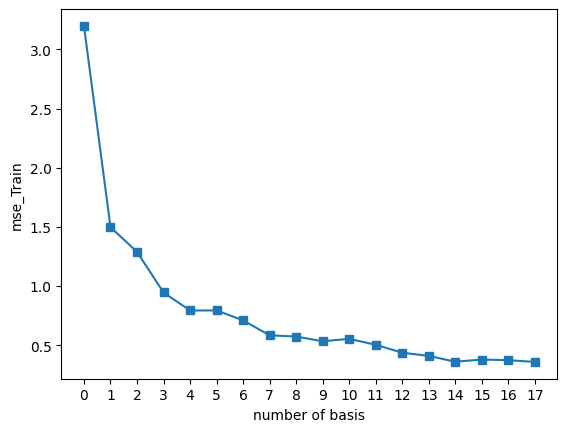

In [ ]:
plt.plot(result_Train_mse,'s-')
plt.xticks(range(0,18))
plt.ylabel('mse_Train')
plt.xlabel('number of basis')

In [ ]:
# Test dataset
result_Test_list, y_Test_predict, result_Test_predict, result_Test_residual, result_Test_mse = hosvdAlgorithm(x_Test, y_Test, S_list, U_list, 18)

In [ ]:
result_Test_predict

np.float64(0.9407075236671649)

In [ ]:
result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']].shape[0]

119

In [ ]:
result_Test_residual[np.where(y_Test == 5)[0][0]]

array([4.32049468, 6.5500766 , 4.91559775, 4.09167079, 6.96057165,
       3.67276995, 5.6587419 , 5.83710136, 5.50868613, 5.99424984])

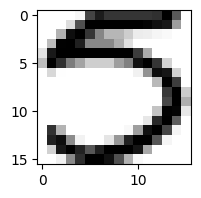

In [ ]:
plot_image(x_Test[np.where(y_Test == 5)[0][0]].reshape([16, 16]))

Predict wrong

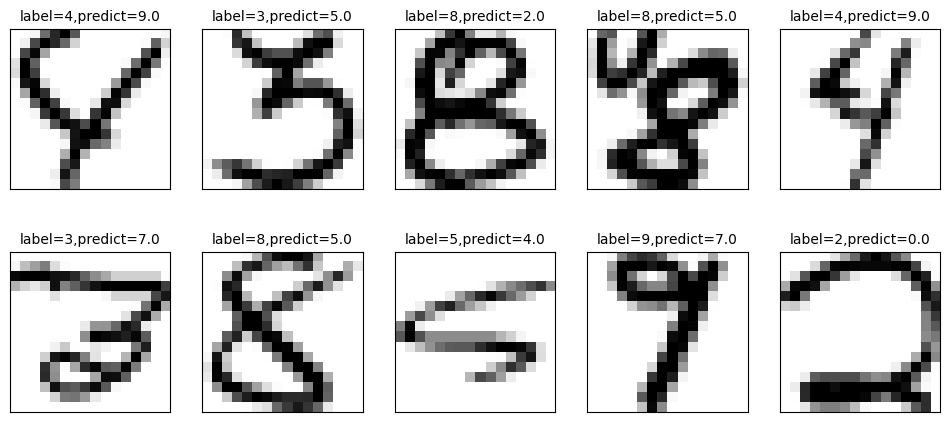

In [ ]:
errorList = result_Test_list[result_Test_list['prediction'] != result_Test_list['actual']]

errorList.shape

plot_images_labels_prediction(errorList.iloc[:,np.arange(0, 256)], errorList.iloc[:,[256]], errorList.iloc[:,[257]],0,10)

In [ ]:
totalCounts = result_Test_list[['actual']].groupby(['actual']).size().reset_index(name='totalCounts')
totalCounts = totalCounts.sort_values('actual', ascending=[True])
errorCounts = errorList[['actual']].groupby(['actual']).size().reset_index(name='errorCounts')
errorCounts = errorCounts.sort_values('actual', ascending=[True])
resultdf = pd.concat([totalCounts,pd.DataFrame(errorCounts, columns=['errorCounts'])], axis=1)
resultdf["successCounts"] = resultdf["totalCounts"]-resultdf["errorCounts"]
resultdf["probability"] = (resultdf["totalCounts"]-resultdf["errorCounts"])/resultdf["totalCounts"]
resultdf.sort_values('probability', ascending=[False])

,actual,totalCounts,errorCounts,successCounts,probability
0,0,359,5,354,0.986072
1,1,264,5,259,0.981061
6,6,170,4,166,0.976471
7,7,147,6,141,0.959184
9,9,177,11,166,0.937853
4,4,200,17,183,0.915000
8,8,166,15,151,0.909639
2,2,198,19,179,0.904040
5,5,160,16,144,0.900000
3,3,166,21,145,0.873494


In [ ]:
# @title
# temp = errorList[['actual', 'prediction']].groupby(['actual', 'prediction']).size().reset_index(name='counts')

# errorPrediction = np.zeros((4, 10))

# for i in range(0,10):
#     errorPrediction[0][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[0,1]
#     errorPrediction[1][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[0,2]
#     errorPrediction[2][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[1,1]
#     errorPrediction[3][i] = temp[temp['actual'] == i].sort_values(['actual', 'counts'], ascending=[True, False]).iloc[1,2]

# pd.DataFrame(errorPrediction, columns=np.arange(0, 10))

In [ ]:
# 計算每個 (digital, prediction) 的錯誤次數
temp = (
    errorList[['actual', 'prediction']]
    .groupby(['actual', 'prediction'])
    .size()
    .reset_index(name='counts')
)

# 建立空的錯誤預測矩陣：4 × 10
errorPrediction = np.zeros((4, 10))

# 對每個真實數字 i，找出最常見的兩個錯誤預測
for i in range(10):
  top_errors = (
      temp[temp['actual'] == i]
      .sort_values('counts', ascending=False)
      .head(2)
  )
  if len(top_errors) > 0:
      errorPrediction[0][i] = top_errors.iloc[0]['prediction']
      errorPrediction[1][i] = top_errors.iloc[0]['counts']
  if len(top_errors) > 1:
      errorPrediction[2][i] = top_errors.iloc[1]['prediction']
      errorPrediction[3][i] = top_errors.iloc[1]['counts']

# 包裝成 DataFrame
error_df = pd.DataFrame(errorPrediction, columns=np.arange(10))
error_df.index = ["1st wrongly predicted digit", "Qty", "2nd wrongly predicted digit", "Qty"]
error_df

,0,1,2,3,4,5,6,7,8,9
1st wrongly predicted digit,1.0,4.0,0.0,5.0,9.0,0.0,5.0,4.0,3.0,4.0
Qty,2.0,3.0,9.0,11.0,6.0,5.0,2.0,3.0,4.0,4.0
2nd wrongly predicted digit,2.0,6.0,4.0,2.0,1.0,3.0,2.0,1.0,0.0,1.0
Qty,1.0,2.0,4.0,3.0,3.0,3.0,1.0,1.0,3.0,3.0


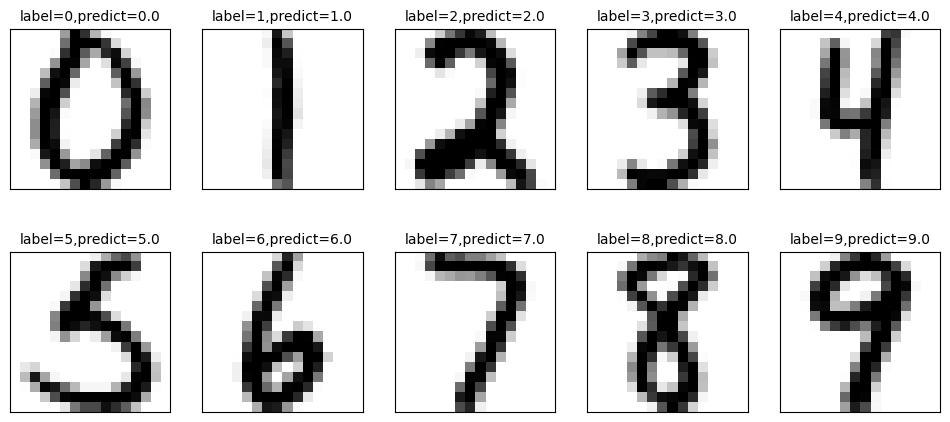

In [ ]:
minList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['min']})


niceIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    niceIndex[i] = int(digitalList[digitalList['residual'] == minList['residual']['min'][i]].index.values[0])

niceList = result_Test_list.iloc[result_Test_list.index.get_indexer(niceIndex)]

plot_images_labels_prediction(niceList.iloc[:,np.arange(0, 256)], niceList.iloc[:,[256]], niceList.iloc[:,[257]],0,10)

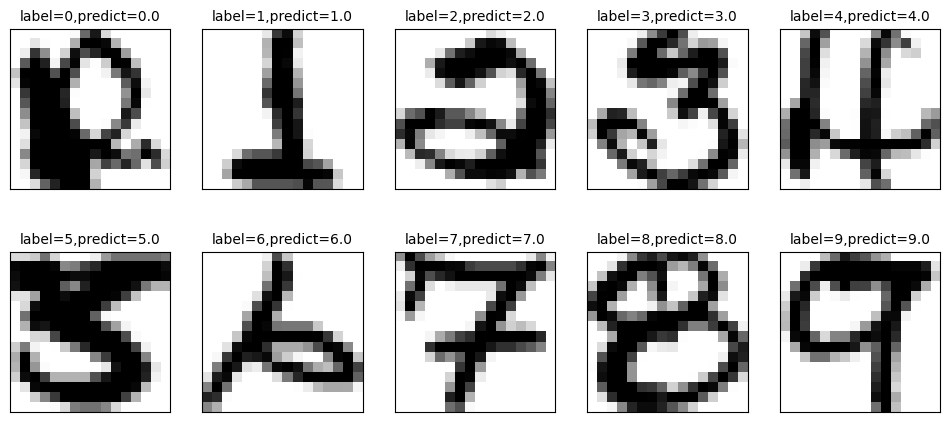

In [ ]:
maxList = result_Test_list[result_Test_list['actual'] == result_Test_list['prediction']].groupby('actual').agg({'residual': ['max']})

uglyIndex = np.zeros(10)

for i in range(0,10):
    digitalList = result_Test_list[result_Test_list['actual'] == i]
    uglyIndex[i] = int(digitalList[digitalList['residual'] == maxList['residual']['max'][i]].index.values[0])

uglyList = result_Test_list.iloc[result_Test_list.index.get_indexer(uglyIndex)]

plot_images_labels_prediction(uglyList.iloc[:,np.arange(0, 256)], uglyList.iloc[:,[256]], uglyList.iloc[:,[257]],0,10)

In [ ]:
result_Test_residual[np.where(y_Test == 3)[0][0]]

array([4.51009391, 6.6180887 , 3.87672432, 2.06638886, 6.1800112 ,
       4.30201718, 5.23869425, 5.28134883, 3.68010053, 5.30493592])

In [ ]:
result_Test_mse

[np.float64(4.022421524663677),
 np.float64(2.0269058295964126),
 np.float64(1.8256103637269556),
 np.float64(1.4867962132536123),
 np.float64(1.2227204783258594),
 np.float64(1.2825112107623318),
 np.float64(1.1629297458893872),
 np.float64(1.1031390134529149),
 np.float64(1.0488290981564523),
 np.float64(0.9725959142999502),
 np.float64(0.9785749875435974),
 np.float64(0.9237668161434978),
 np.float64(0.9182859990034878),
 np.float64(0.9157947184853015),
 np.float64(0.9088191330343797),
 np.float64(0.8629795714997509),
 np.float64(0.9466865969108121),
 np.float64(0.9387144992526159)]

Text(0.5, 0, 'number of basis')

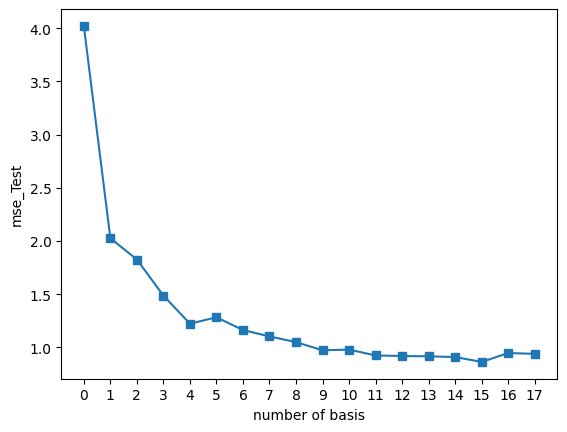

In [ ]:
plt.plot(result_Test_mse,'s-')
plt.xticks(range(0,18))
plt.ylabel('mse_Test')
plt.xlabel('number of basis')

Digit 0

In [ ]:
components = np.where(y_Test == 0)[0]
components
x_Test_0 = x_Test[components, :]
y_Test_0 = np.full(x_Test_0.shape[0],0)

In [ ]:
result_Test_0_list, y_Test_0_predict, result_Test_0_predict, result_Test_0_residual, result_Test_0_mse = hosvdAlgorithm(x_Test_0, y_Test_0, S_list, U_list, 18)

In [ ]:
result_Test_0_predict

np.float64(0.9860724233983287)

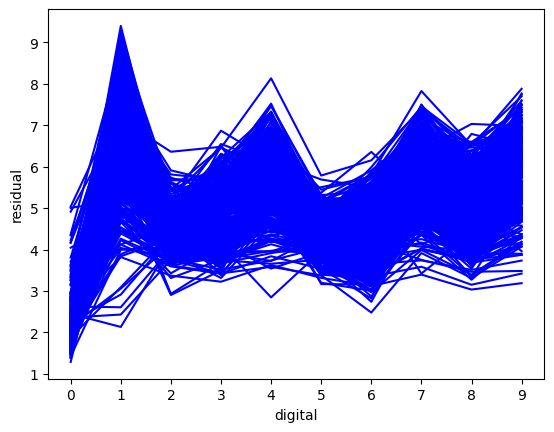

In [ ]:
plt.xticks(range(0,18))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_0.shape[0]):
    plt.plot(result_Test_0_residual[i],color = 'blue')

Digit 1

In [ ]:
components = np.where(y_Test == 1)[0]
components
x_Test_1 = x_Test[components, :]
y_Test_1 = np.full(x_Test_1.shape[0],1)

In [ ]:
result_Test_1_list, y_Test_1_predict, result_Test_1_predict, result_Test_1_residual, result_Test_1_mse = hosvdAlgorithm(x_Test_1, y_Test_1, S_list, U_list, 18)

In [ ]:
result_Test_1_predict

np.float64(0.9810606060606061)

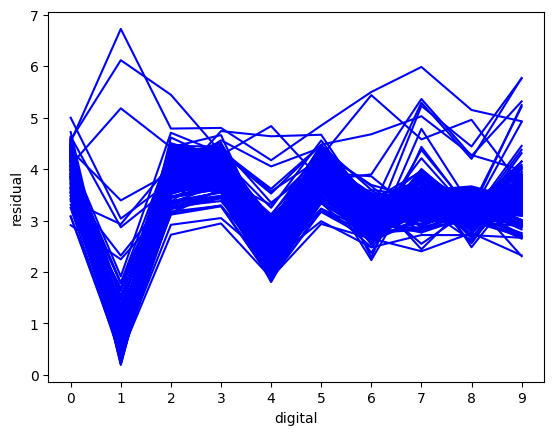

In [ ]:
plt.xticks(range(0,18))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_1.shape[0]):
    plt.plot(result_Test_1_residual[i],color = 'blue')

Digit 5

In [ ]:
components = np.where(y_Test == 5)[0]
components
x_Test_5 = x_Test[components, :]
y_Test_5 = np.full(x_Test_5.shape[0],5)

In [ ]:
result_Test_5_list, y_Test_5_predict, result_Test_5_predict, result_Test_5_residual, result_Test_5_mse = hosvdAlgorithm(x_Test_5, y_Test_5, S_list, U_list, 18)

In [ ]:
result_Test_5_predict

np.float64(0.9)

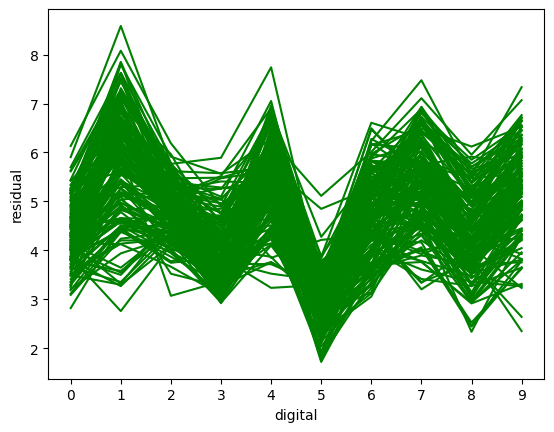

In [ ]:
plt.xticks(range(0,18))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_5.shape[0]):
    plt.plot(result_Test_5_residual[i],color = 'green')

Digit 3

In [ ]:
components = np.where(y_Test == 3)[0]
components
x_Test_3 = x_Test[components, :]
y_Test_3 = np.full(x_Test_3.shape[0],3)

In [ ]:
result_Test_3_list, y_Test_3_predict, result_Test_3_predict, result_Test_3_residual, result_Test_3_mse = hosvdAlgorithm(x_Test_3, y_Test_3, S_list, U_list, 18)

In [ ]:
result_Test_3_predict

np.float64(0.8734939759036144)

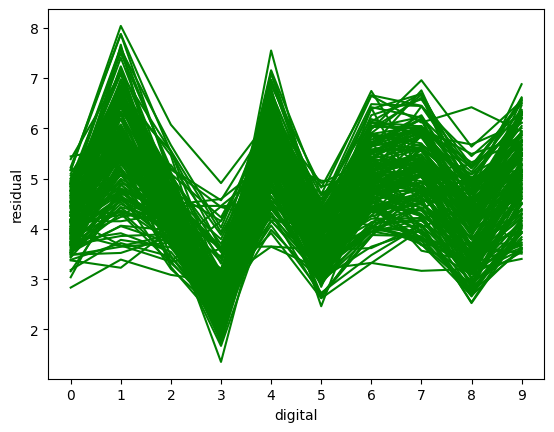

In [ ]:
plt.xticks(range(0,18))
plt.ylabel('residual')
plt.xlabel('digital')
for i in range(x_Test_3.shape[0]):
    plt.plot(result_Test_3_residual[i],color = 'green')

My own data

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son1_list, y_son1_predict, result_son1_predict, result_son1_residual, result_son1_mse = hosvdAlgorithm(x_son1, y_son1, S_list, U_list, 18)
result_son1_predict

np.float64(0.9)

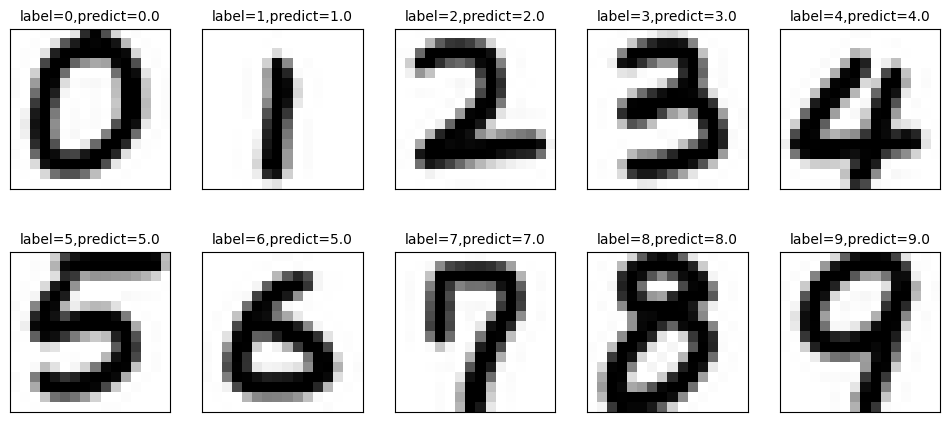

In [ ]:
plot_images_labels_prediction(result_son1_list.iloc[:,np.arange(0, 256)], result_son1_list.iloc[:,[256]], result_son1_list.iloc[:,[257]],0,10)

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son2_list, y_son2_predict, result_son2_predict, result_son2_residual, result_son2_mse = hosvdAlgorithm(x_son2, y_son2, S_list, U_list, 18)
result_son2_predict

np.float64(0.6)

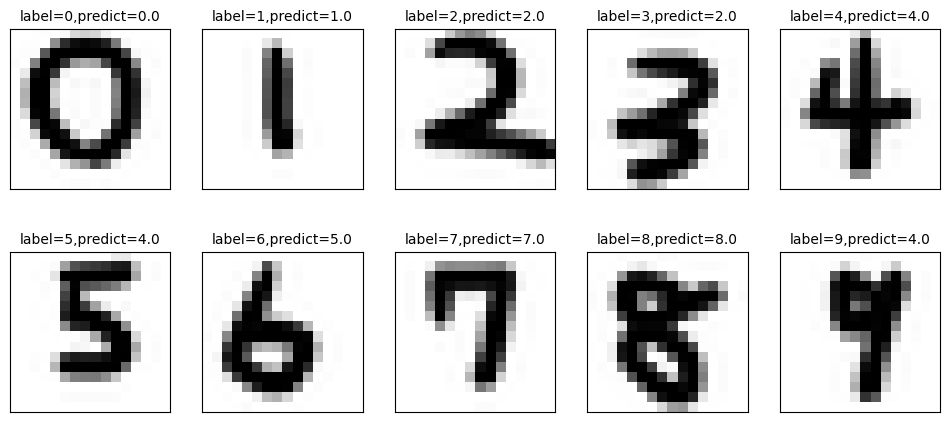

In [ ]:
plot_images_labels_prediction(result_son2_list.iloc[:,np.arange(0, 256)], result_son2_list.iloc[:,[256]], result_son2_list.iloc[:,[257]],0,10)

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
result_son3_list, y_son3_predict, result_son3_predict, result_son3_residual, result_son3_mse = hosvdAlgorithm(x_son3, y_son3, S_list, U_list, 18)
result_son3_predict

np.float64(0.4)

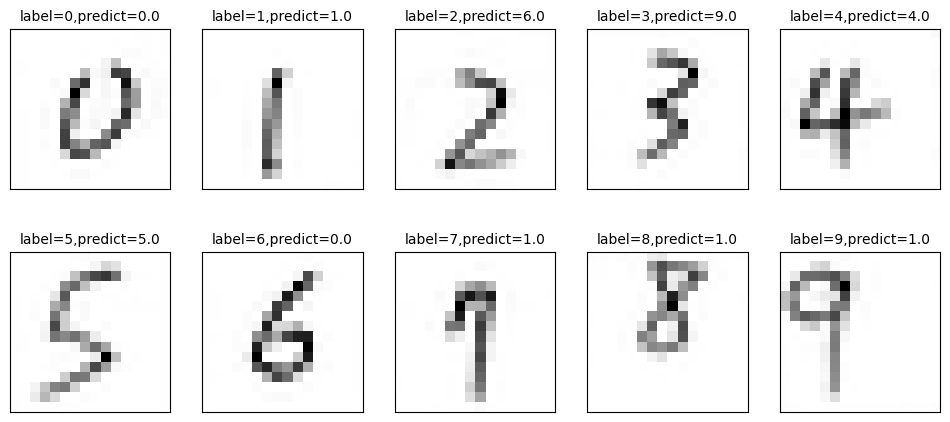

In [ ]:
plot_images_labels_prediction(result_son3_list.iloc[:,np.arange(0, 256)], result_son3_list.iloc[:,[256]], result_son3_list.iloc[:,[257]],0,10)

In [ ]:
# @title
# Record all the results
overall_pred_res("HoSVD", [result_Test_predict, result_son1_predict, result_son2_predict])

# Classification Using Random Forest (隨機森林演算法)

In [ ]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, classification_report, accuracy_score

In [ ]:
forest = RandomForestClassifier(criterion='gini',
                                n_estimators=300,
                                max_depth = 10,
                                max_features='sqrt',
                                min_samples_split=4,
                                min_samples_leaf=2,
                                random_state=3,
                                n_jobs=2)

In [ ]:
forest.fit(x_Train,y_Train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=4,
                       n_estimators=300, n_jobs=2, random_state=3)

In [ ]:
y_Train_pred = forest.predict(x_Train)
accuracy_score(y_Train, y_Train_pred)

0.9969825812645727

In [ ]:
y_Test_pred = forest.predict(x_Test)

In [ ]:
prediction_data = pd.concat([pd.DataFrame(y_Test, columns=['actual']), pd.DataFrame(y_Test_pred, columns=['prediction'])], axis=1)

result = prediction_data[prediction_data['actual'] == prediction_data['prediction']].shape[0]/prediction_data.shape[0]
result

0.9377179870453413

In [ ]:
accuracy_score(y_Test, y_Test_pred)

0.9377179870453413

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)).flatten()

In [ ]:
y_son1_pred = forest.predict(x_son1)

In [ ]:
prediction_data = pd.concat([pd.DataFrame(y_son1, columns=['actual']), pd.DataFrame(y_son1_pred, columns=['prediction'])], axis=1)

result_son1_predict = prediction_data[prediction_data['actual'] == prediction_data['prediction']].shape[0]/prediction_data.shape[0]
result_son1_predict

0.6

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)).flatten()

In [ ]:
y_son2_pred = forest.predict(x_son2)

In [ ]:
prediction_data = pd.concat([pd.DataFrame(y_son2, columns=['actual']), pd.DataFrame(y_son2_pred, columns=['prediction'])], axis=1)

result_son2_predict = prediction_data[prediction_data['actual'] == prediction_data['prediction']].shape[0]/prediction_data.shape[0]
result_son2_predict

0.5

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)).flatten()

In [ ]:
y_son3_pred = forest.predict(x_son3)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print(accuracy_score(y_son3, y_son3_pred))

0.1


In [ ]:
# Record all the results
overall_pred_res("RandomForest", [result, result_son1_predict, result_son2_predict])

,Mean,SVD,HoSVD,RandomForest
test accuracy,0.776781,0.934728,0.934728,0.916791
my data 1,0.500000,0.700000,0.700000,0.700000
my data 2,0.600000,0.300000,0.300000,0.300000


# Other ML Models: SVM/DecisionTree/Voting/Bagging/Boosting/Stacking

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    VotingClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression


# 3. 定義基礎模型
svm_clf = SVC(kernel="rbf", gamma="scale", C=5, probability=True, random_state=42)
dt_clf = DecisionTreeClassifier(max_depth=30, max_features='sqrt', random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Voting (硬投票 / 軟投票)
voting_clf = VotingClassifier(
    estimators=[("svm", svm_clf), ("dt", dt_clf), ("rf", rf_clf)],
    voting="soft"   # "hard" 也可
)

# 5. Bagging (以 Decision Tree 為基底)
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

# 6. Boosting (AdaBoost + GradientBoosting)
adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# 7. Stacking (以 Logistic Regression 為次級分類器)
stacking_clf = StackingClassifier(
    estimators=[("svm", svm_clf), ("dt", dt_clf), ("rf", rf_clf)],
    final_estimator=LogisticRegression(max_iter=100),
    passthrough=True
)

# 8. 模型清單
models = {
    "SVM": svm_clf,
    "DecisionTree": dt_clf,
    "Voting": voting_clf,
    "Bagging": bagging_clf,
    "AdaBoost": adaboost_clf,
    "GradientBoosting": gb_clf,
    "Stacking": stacking_clf
}

# 9. 訓練 & 評估
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(x_Train, y_Train)
    y_pred = model.predict(x_Test)
    acc = accuracy_score(y_Test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_Test, y_pred, digits=4))

# 10. 總結比較
print("\n=== Model Comparison ===")
for name, acc in results.items():
    print(f"{name}: {acc}")


Training SVM...
SVM Accuracy: 0.9532
              precision    recall  f1-score   support

           0     0.9779    0.9861    0.9820       359
           1     0.9961    0.9735    0.9847       264
           2     0.9394    0.9394    0.9394       198
           3     0.9427    0.8916    0.9164       166
           4     0.8957    0.9450    0.9197       200
           5     0.9091    0.9375    0.9231       160
           6     0.9645    0.9588    0.9617       170
           7     0.9859    0.9524    0.9689       147
           8     0.9341    0.9398    0.9369       166
           9     0.9551    0.9605    0.9577       177

    accuracy                         0.9532      2007
   macro avg     0.9501    0.9484    0.9490      2007
weighted avg     0.9537    0.9532    0.9533      2007


Training DecisionTree...
DecisionTree Accuracy: 0.7833
              precision    recall  f1-score   support

           0     0.9114    0.8886    0.8999       359
           1     0.9643    0.9205    0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stacking Accuracy: 0.9407
              precision    recall  f1-score   support

           0     0.9694    0.9721    0.9708       359
           1     0.9883    0.9621    0.9750       264
           2     0.9330    0.9141    0.9235       198
           3     0.9187    0.8855    0.9018       166
           4     0.9069    0.9250    0.9158       200
           5     0.8976    0.9313    0.9141       160
           6     0.9318    0.9647    0.9480       170
           7     0.9452    0.9388    0.9420       147
           8     0.9096    0.9096    0.9096       166
           9     0.9551    0.9605    0.9577       177

    accuracy                         0.9407      2007
   macro avg     0.9356    0.9364    0.9358      2007
weighted avg     0.9410    0.9407    0.9407      2007


=== Model Comparison ===
SVM: 0.9531639262580966
DecisionTree: 0.7832585949177877
Voting: 0.9267563527653214
Bagging: 0.8973592426507224
AdaBoost: 0.815146985550573
GradientBoosting: 0.9202790234180369
Stacking: 0.

In [ ]:
y_son = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))
x_son2 = np.zeros((10,256))
x_son3 = np.zeros((10,256))

for i in range(10):
  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
  x_son1[i,:] = (np.array(img)/255).flatten()

  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
  x_son2[i,:] = (np.array(img)/255).flatten()

  img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
  x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
from sklearn.metrics import accuracy_score

results1 = {}
results2 = {}
results3 = {}
for name, model in models.items():
    # print(f"\nTraining {name}...")
    # model.fit(X_train, y_train)          # 訓練模型
    y_son1_pred = model.predict(x_son1)       # 測試集預測
    acc = accuracy_score(y_son, y_son1_pred) # 計算 accuracy
    results1[name] = acc
    print(f"{name} Accuracy: son1 {acc}")

    y_son2_pred = model.predict(x_son2)       # 測試集預測
    acc1 = accuracy_score(y_son, y_son2_pred) # 計算 accuracy
    results2[name] = acc1
    print(f"{name} Accuracy: son2 {acc1}")

    y_son3_pred = model.predict(x_son3)       # 測試集預測
    acc2 = accuracy_score(y_son, y_son3_pred) # 計算 accuracy
    results3[name] = acc2
    print(f"{name} Accuracy: son3 {acc2}")

# 總結比較
print("\n=== Model Comparison ===")
for name, acc in results1.items():
    print(f"{name}: son1 {acc}")

for name, acc in results2.items():
    print(f"{name}: son2 {acc}")

for name, acc in results3.items():
    print(f"{name}: son3 {acc}")

SVM Accuracy: son1 1.0
SVM Accuracy: son2 0.7
SVM Accuracy: son3 0.1
DecisionTree Accuracy: son1 0.2
DecisionTree Accuracy: son2 0.2
DecisionTree Accuracy: son3 0.0
Voting Accuracy: son1 0.6
Voting Accuracy: son2 0.5
Voting Accuracy: son3 0.0
Bagging Accuracy: son1 0.6
Bagging Accuracy: son2 0.4
Bagging Accuracy: son3 0.4
AdaBoost Accuracy: son1 0.6
AdaBoost Accuracy: son2 0.3
AdaBoost Accuracy: son3 0.2
GradientBoosting Accuracy: son1 0.7
GradientBoosting Accuracy: son2 0.6
GradientBoosting Accuracy: son3 0.1
Stacking Accuracy: son1 1.0
Stacking Accuracy: son2 0.6
Stacking Accuracy: son3 0.0

=== Model Comparison ===
SVM: son1 1.0
DecisionTree: son1 0.2
Voting: son1 0.6
Bagging: son1 0.6
AdaBoost: son1 0.6
GradientBoosting: son1 0.7
Stacking: son1 1.0
SVM: son2 0.7
DecisionTree: son2 0.2
Voting: son2 0.5
Bagging: son2 0.4
AdaBoost: son2 0.3
GradientBoosting: son2 0.6
Stacking: son2 0.6
SVM: son3 0.1
DecisionTree: son3 0.0
Voting: son3 0.0
Bagging: son3 0.4
AdaBoost: son3 0.2
GradientB

In [ ]:
# Record all the results
for idx, (name, acc) in enumerate(results.items()):
  # print(idx,name,acc)
  table = overall_pred_res(name, [acc, results1[name], results2[name]])

table

,Mean,SVD,HoSVD,RandomForest,SVM,DecisionTree,Voting,Bagging,AdaBoost,GradientBoosting,Stacking
test accuracy,0.776781,0.934728,0.934728,0.916791,0.953164,0.829098,0.927255,0.897359,0.840558,0.927753,0.942701
my data 1,0.500000,0.700000,0.700000,0.700000,1.000000,0.400000,0.700000,0.600000,0.300000,0.800000,1.000000
my data 2,0.600000,0.300000,0.300000,0.300000,0.700000,0.300000,0.400000,0.400000,0.500000,0.600000,0.500000


# Classification Using MLP (多層感知器)

In [ ]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [ ]:
# @title
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
model = Sequential([
    Input(shape=(256,)),  # ✅ 用 Input() 明確定義輸入形狀
    Dense(256, kernel_initializer='normal', activation='relu'),
    Dense(256, kernel_initializer='normal', activation='relu'),
    Dense(10, kernel_initializer='normal', activation='softmax')
])

In [ ]:
# @title
model = Sequential()
model.add(Dense(input_dim=256,
                units=256,
                kernel_initializer='normal',
                activation='relu'))

model.add(Dense(units=256,
                kernel_initializer='normal',
                activation='relu'))

model.add(Dense(units=10,
                kernel_initializer='normal',
                activation='softmax'))

In [ ]:
# @title
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

train_history = model.fit(
    x=x_Train,
    y=y_TrainOneHot,
    validation_split=0.2,
    epochs=20,
    batch_size=300,
    verbose=2,
    callbacks=callbacks
)

In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train,
                        y=y_TrainOneHot,validation_split=0.2,
                        epochs=20, batch_size=300,verbose=2)

Epoch 1/20
20/20 - 4s - 216ms/step - accuracy: 0.9964 - loss: 0.0121 - val_accuracy: 0.9637 - val_loss: 0.1343
Epoch 2/20
20/20 - 1s - 68ms/step - accuracy: 0.9988 - loss: 0.0077 - val_accuracy: 0.9664 - val_loss: 0.1309
Epoch 3/20
20/20 - 1s - 31ms/step - accuracy: 0.9997 - loss: 0.0057 - val_accuracy: 0.9719 - val_loss: 0.1117
Epoch 4/20
20/20 - 1s - 36ms/step - accuracy: 0.9986 - loss: 0.0059 - val_accuracy: 0.9678 - val_loss: 0.1164
Epoch 5/20
20/20 - 1s - 55ms/step - accuracy: 0.9993 - loss: 0.0047 - val_accuracy: 0.9657 - val_loss: 0.1350
Epoch 6/20
20/20 - 1s - 33ms/step - accuracy: 0.9998 - loss: 0.0032 - val_accuracy: 0.9671 - val_loss: 0.1266
Epoch 7/20
20/20 - 1s - 25ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 0.9698 - val_loss: 0.1217
Epoch 8/20
20/20 - 1s - 30ms/step - accuracy: 0.9998 - loss: 0.0026 - val_accuracy: 0.9705 - val_loss: 0.1255
Epoch 9/20
20/20 - 1s - 31ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.9685 - val_loss: 0.1188
Epoch 10/

In [ ]:
scores_test = model.evaluate(x_Test , y_TestOneHot)
scores_test[1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9401 - loss: 0.3876


0.9357249736785889

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son1 , y_son1OneHot)
scores_son1[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8000 - loss: 0.6921


0.800000011920929

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
y_son2OneHot =to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son2 , y_son2OneHot)
scores_son2[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6000 - loss: 4.9082


0.6000000238418579

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
y_son3OneHot =to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son3 , y_son3OneHot)
scores_son3[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.1000 - loss: 4.9798


0.10000000149011612

In [ ]:
# Record all the results
overall_pred_res("MLP", [scores_test[1], scores_son1[1], scores_son2[1]])

,Mean,SVD,HoSVD,RandomForest,SVM,DecisionTree,Voting,Bagging,AdaBoost,GradientBoosting,Stacking,MLP
test accuracy,0.776781,0.934728,0.934728,0.916791,0.953164,0.829098,0.927255,0.897359,0.840558,0.927753,0.942701,0.931241
my data 1,0.500000,0.700000,0.700000,0.700000,1.000000,0.400000,0.700000,0.600000,0.300000,0.800000,1.000000,0.800000
my data 2,0.600000,0.300000,0.300000,0.300000,0.700000,0.300000,0.400000,0.400000,0.500000,0.600000,0.500000,0.500000


# Classification Using CNN (卷積神經網路)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [ ]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
x_Train_tensor = x_Train.reshape(len(x_Train), 16, 16).astype('float32')
x_Test_tensor = x_Test.reshape(len(x_Test), 16, 16).astype('float32')

In [ ]:
# 多加一個顏色的維度
x_Train4D=x_Train_tensor.reshape(x_Train_tensor.shape[0],16,16,1).astype('float32')
x_Test4D=x_Test_tensor.reshape(x_Test_tensor.shape[0],16,16,1).astype('float32')

In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential([
    # ✅ 使用 Input() 明確定義輸入形狀
    Input(shape=(16, 16, 1)),

    # 第一層卷積 + Pooling
    Conv2D(filters=16, kernel_size=(5, 5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # 第二層卷積 + Pooling
    Conv2D(filters=36, kernel_size=(5, 5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Dropout 防止 overfitting
    Dropout(0.25),

    # 平坦化
    Flatten(),

    # 全連接層
    Dense(units=256, activation='relu'),
    Dropout(0.5),
    Dense(units=10, activation='softmax')  # 多分類輸出
])

In [ ]:
# @title
# # define network structure

# model = Sequential()

# # initializing CNN

# # 一個 Convolution Operation 搭配 一個 Pooling

# # 二維卷積層 : filter為16, Kernel size為(5,5),Padding為(same)
# model.add(Conv2D(filters=16,
#                  kernel_size=(5,5),
#                  padding='same',
#                  input_shape=(16,16,1),
#                  activation='relu'))

# # MaxPooling size為(2,2)
# model.add(MaxPooling2D(pool_size=(2, 2)))

# # Second convolutional layer

# model.add(Conv2D(filters=36,
#                  kernel_size=(5,5),
#                  padding='same',
#                  activation='relu'))

# model.add(MaxPooling2D(pool_size=(2, 2)))

# # Drop掉部分神經元避免overfitting
# model.add(Dropout(0.25))

# # 平坦化
# model.add(Flatten())

# # Fully Connected Networks

# model.add(Dense(units=256, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(units=10,activation='softmax'))

In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train4D,
            y=y_TrainOneHot,validation_split=0.2,
            epochs=20, batch_size=300,verbose=2)

Epoch 1/20
20/20 - 5s - 259ms/step - accuracy: 0.4285 - loss: 1.7036 - val_accuracy: 0.7855 - val_loss: 0.7786
Epoch 2/20
20/20 - 3s - 164ms/step - accuracy: 0.7972 - loss: 0.6331 - val_accuracy: 0.9075 - val_loss: 0.3096
Epoch 3/20
20/20 - 4s - 213ms/step - accuracy: 0.8933 - loss: 0.3419 - val_accuracy: 0.9287 - val_loss: 0.2114
Epoch 4/20
20/20 - 2s - 110ms/step - accuracy: 0.9227 - loss: 0.2523 - val_accuracy: 0.9520 - val_loss: 0.1602
Epoch 5/20
20/20 - 3s - 164ms/step - accuracy: 0.9383 - loss: 0.2042 - val_accuracy: 0.9548 - val_loss: 0.1426
Epoch 6/20
20/20 - 5s - 230ms/step - accuracy: 0.9480 - loss: 0.1768 - val_accuracy: 0.9582 - val_loss: 0.1207
Epoch 7/20
20/20 - 4s - 184ms/step - accuracy: 0.9595 - loss: 0.1406 - val_accuracy: 0.9650 - val_loss: 0.0971
Epoch 8/20
20/20 - 4s - 182ms/step - accuracy: 0.9614 - loss: 0.1262 - val_accuracy: 0.9664 - val_loss: 0.0964
Epoch 9/20
20/20 - 3s - 138ms/step - accuracy: 0.9630 - loss: 0.1181 - val_accuracy: 0.9685 - val_loss: 0.0862
E

In [ ]:
scores_test = model.evaluate(x_Test4D , y_TestOneHot)
scores_test[1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9622 - loss: 0.1245


0.9586447477340698

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son1_tensor = x_son1.reshape(len(x_son1), 16, 16).astype('float32')
x_son14D=x_son1_tensor.reshape(x_son1_tensor.shape[0],16,16,1).astype('float32')
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son14D , y_son1OneHot)
scores_son1[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9000 - loss: 0.2447


0.8999999761581421

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_tensor = x_son2.reshape(len(x_son2), 16, 16).astype('float32')
x_son24D=x_son2_tensor.reshape(x_son2_tensor.shape[0],16,16,1).astype('float32')
y_son2OneHot = to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son24D , y_son2OneHot)
scores_son2[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8000 - loss: 0.2252


0.800000011920929

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_tensor = x_son3.reshape(len(x_son3), 16, 16).astype('float32')
x_son34D=x_son3_tensor.reshape(x_son3_tensor.shape[0],16,16,1).astype('float32')
y_son3OneHot = to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son34D , y_son3OneHot)
scores_son3[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4000 - loss: 1.8777


0.4000000059604645

In [ ]:
# Record all the results
overall_pred_res("CNN", [scores_test[1], scores_son1[1], scores_son2[1]])

,Mean,SVD,HoSVD,RandomForest,SVM,DecisionTree,Voting,Bagging,AdaBoost,GradientBoosting,Stacking,MLP,RNN,CNN
test accuracy,0.776781,0.934728,0.934728,0.916791,0.953164,0.829098,0.927255,0.897359,0.840558,0.927753,0.942701,0.931241,0.92277,0.95715
my data 1,0.500000,0.700000,0.700000,0.700000,1.000000,0.400000,0.700000,0.600000,0.300000,0.800000,1.000000,0.800000,0.70000,0.90000
my data 2,0.600000,0.300000,0.300000,0.300000,0.700000,0.300000,0.400000,0.400000,0.500000,0.600000,0.500000,0.500000,0.60000,0.90000


# Classification Using RNN (循環神經網路)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Dropout,SimpleRNN
from tensorflow.keras.utils import to_categorical

In [ ]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
x_Train_tensor = x_Train.reshape(len(x_Train), 16, 16).astype('float32')
x_Test_tensor = x_Test.reshape(len(x_Test), 16, 16).astype('float32')

In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dropout, Dense

model = Sequential([
    Input(shape=(16, 16)),  # ✅ 使用 Input() 定義時間步長與特徵數
    SimpleRNN(units=256, unroll=True),
    Dropout(0.1),
    Dense(units=10, kernel_initializer='normal', activation='softmax')
])

In [ ]:
# @title
# # define network structure

# model = Sequential()

# model.add(SimpleRNN(input_shape=(16,16),
#                     units = 256,
#                     unroll=True))

# model.add(Dropout(0.1))

# model.add(Dense(units=10,kernel_initializer='normal',activation='softmax'))

In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train_tensor,
            y=y_TrainOneHot,validation_split=0.2,
            epochs=20, batch_size=300,verbose=2)

Epoch 1/20
20/20 - 3s - 172ms/step - accuracy: 0.6638 - loss: 1.1749 - val_accuracy: 0.8492 - val_loss: 0.6008
Epoch 2/20
20/20 - 1s - 52ms/step - accuracy: 0.8882 - loss: 0.4225 - val_accuracy: 0.9054 - val_loss: 0.3155
Epoch 3/20
20/20 - 1s - 54ms/step - accuracy: 0.9278 - loss: 0.2602 - val_accuracy: 0.9376 - val_loss: 0.2184
Epoch 4/20
20/20 - 1s - 63ms/step - accuracy: 0.9427 - loss: 0.2033 - val_accuracy: 0.9397 - val_loss: 0.1914
Epoch 5/20
20/20 - 2s - 91ms/step - accuracy: 0.9503 - loss: 0.1707 - val_accuracy: 0.9527 - val_loss: 0.1712
Epoch 6/20
20/20 - 2s - 103ms/step - accuracy: 0.9602 - loss: 0.1491 - val_accuracy: 0.9472 - val_loss: 0.1641
Epoch 7/20
20/20 - 2s - 94ms/step - accuracy: 0.9552 - loss: 0.1476 - val_accuracy: 0.9500 - val_loss: 0.1550
Epoch 8/20
20/20 - 2s - 90ms/step - accuracy: 0.9588 - loss: 0.1411 - val_accuracy: 0.9493 - val_loss: 0.1543
Epoch 9/20
20/20 - 1s - 52ms/step - accuracy: 0.9679 - loss: 0.1160 - val_accuracy: 0.9561 - val_loss: 0.1521
Epoch 10

In [ ]:
scores_test = model.evaluate(x_Test_tensor , y_TestOneHot)
scores_test[1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9327 - loss: 0.2440


0.9357249736785889

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son1_tensor = x_son1.reshape(len(x_son1), 16, 16).astype('float32')
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son1_tensor , y_son1OneHot)
scores_son1[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8000 - loss: 0.7040


0.800000011920929

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_tensor = x_son2.reshape(len(x_son2), 16, 16).astype('float32')
y_son2OneHot = to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son2_tensor , y_son2OneHot)
scores_son2[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8000 - loss: 0.6648


0.800000011920929

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_tensor = x_son3.reshape(len(x_son3), 16, 16).astype('float32')
y_son3OneHot = to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son3_tensor , y_son3OneHot)
scores_son3[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.2000 - loss: 6.0274


0.20000000298023224

In [ ]:
# @title
# Record all the results
overall_pred_res("RNN", [scores_test[1], scores_son1[1], scores_son2[1]])

# Classification Using LSTM (長短期記憶循環神經網路)

In [ ]:
from keras.models import Sequential
from tensorflow.keras.layers import LSTM

In [ ]:
x_Train, y_Train, x_Test, y_Test = getUspDataSet(path)
print("training set (16x16) : %d piece(s)" % x_Train.shape[0])
print("testing set (16x16) : %d piece(s)" % x_Test.shape[0])

training set (16x16) : 7291 piece(s)
testing set (16x16) : 2007 piece(s)


In [ ]:
x_Train_tensor = x_Train.reshape(len(x_Train), 16, 16).astype('float32')
x_Test_tensor = x_Test.reshape(len(x_Test), 16, 16).astype('float32')

In [ ]:
# 把類別做Onehot encoding
y_TrainOneHot = to_categorical(y_Train)
y_TestOneHot = to_categorical(y_Test)

In [ ]:
model = Sequential([
    Input(shape=(16, 16)),               # ✅ 定義輸入：16 時間步 × 16 特徵
    LSTM(units=256, unroll=False),      # LSTM 層，256 單元
    Dropout(0.1),                        # Dropout 防止過擬合
    Dense(units=10, kernel_initializer='normal', activation='softmax')  # 多分類輸出
])


In [ ]:
# @title
# model = Sequential()

# model.add(LSTM(input_shape=(16, 16),
#                 units=256,
#                 unroll=False))

# model.add(Dropout(0.1))

# model.add(Dense(units=10,kernel_initializer='normal',activation='softmax'))

In [ ]:
# 訓練模型
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['accuracy'])

train_history=model.fit(x=x_Train_tensor,
                        y=y_TrainOneHot,validation_split=0.2,
                        epochs=20, batch_size=300,verbose=2)

Epoch 1/20
20/20 - 11s - 543ms/step - accuracy: 0.9590 - loss: 0.1303 - val_accuracy: 0.9719 - val_loss: 0.0958
Epoch 2/20
20/20 - 2s - 98ms/step - accuracy: 0.9858 - loss: 0.0514 - val_accuracy: 0.9698 - val_loss: 0.0941
Epoch 3/20
20/20 - 2s - 90ms/step - accuracy: 0.9913 - loss: 0.0336 - val_accuracy: 0.9719 - val_loss: 0.0904
Epoch 4/20
20/20 - 1s - 54ms/step - accuracy: 0.9930 - loss: 0.0271 - val_accuracy: 0.9698 - val_loss: 0.0959
Epoch 5/20
20/20 - 2s - 85ms/step - accuracy: 0.9943 - loss: 0.0229 - val_accuracy: 0.9712 - val_loss: 0.0985
Epoch 6/20
20/20 - 2s - 95ms/step - accuracy: 0.9959 - loss: 0.0212 - val_accuracy: 0.9753 - val_loss: 0.0893
Epoch 7/20
20/20 - 1s - 71ms/step - accuracy: 0.9950 - loss: 0.0216 - val_accuracy: 0.9774 - val_loss: 0.0853
Epoch 8/20
20/20 - 2s - 115ms/step - accuracy: 0.9974 - loss: 0.0183 - val_accuracy: 0.9719 - val_loss: 0.1014
Epoch 9/20
20/20 - 1s - 64ms/step - accuracy: 0.9957 - loss: 0.0192 - val_accuracy: 0.9760 - val_loss: 0.0880
Epoch 1

In [ ]:
scores_test = model.evaluate(x_Test_tensor , y_TestOneHot)
scores_test[1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9261 - loss: 0.3322


0.9207772612571716

In [ ]:
y_son1 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son1 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son1/" + str(i) +".png", "r").convert("L")
    x_son1[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son1_tensor = x_son1.reshape(len(x_son1), 16, 16).astype('float32')
y_son1OneHot = to_categorical(y_son1)

In [ ]:
scores_son1 = model.evaluate(x_son1_tensor , y_son1OneHot)
scores_son1[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7000 - loss: 1.7327


0.699999988079071

In [ ]:
y_son2 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son2 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son2/" + str(i) +".png", "r").convert("L")
    x_son2[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son2_tensor = x_son2.reshape(len(x_son2), 16, 16).astype('float32')
y_son2OneHot = to_categorical(y_son2)

In [ ]:
scores_son2 = model.evaluate(x_son2_tensor , y_son2OneHot)
scores_son2[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6000 - loss: 1.2928


0.6000000238418579

In [ ]:
y_son3 = np.array([0,1,2,3,4,5,6,7,8,9])
x_son3 = np.zeros((10,256))

for i in range(10):
    img = Image.open("drive/MyDrive/Colab Notebooks/mathAnalysis/test_dataset/16x16/son3/" + str(i) +".png", "r").convert("L")
    x_son3[i,:] = (np.array(img)/255).flatten()

In [ ]:
x_son3_tensor = x_son3.reshape(len(x_son3), 16, 16).astype('float32')
y_son3OneHot = to_categorical(y_son3)

In [ ]:
scores_son3 = model.evaluate(x_son3_tensor , y_son3OneHot)
scores_son3[1]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.1000 - loss: 6.8386


0.10000000149011612

In [ ]:
# @title
# Record all the results
overall_pred_res("LSTM", [scores_test[1], scores_son1[1], scores_son2[1]])

# Show overall the results


In [ ]:
# @title
df_table